In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
import itertools
import scipy
from scipy.interpolate import interp1d

load in the models to be run using a csv file like the following:

For the gain model for svet07 and ga, you can choose between sec (sector model), pham (pham model with n= the value in the n column), or simp (simple model where the volatiles gained are the impactor mass times the volatile fraction)

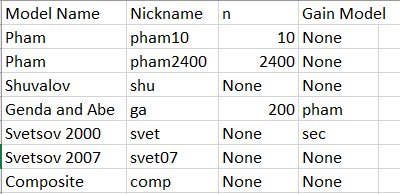

In [4]:
mods=pd.read_csv('models.csv')
display(mods)

,Model Name,Nickname,n,Gain Model
0,Pham,pham10,10,None
1,Pham,pham2400,2400,None
2,Shuvalov,shu,None,None
3,Genda and Abe,ga,None,sec
4,Svetsov 2000,svet,None,sec
5,Svetsov 2007,svet07,None,None
6,Composite,comp,None,None


In [5]:
print('running the following models:')
for i in range(len(mods['Model Name'])):
  if mods['Model Name'][i]=='Pham' or mods['Model Name'][i]=='Genda and Abe':
    print(mods['Model Name'][i],'(n='+str(mods['n'][i])+')')
  else:
    print(mods['Model Name'][i])

running the following models:
Pham (n=10)
Pham (n=2400)
Shuvalov
Genda and Abe (n=None)
Svetsov 2000
Svetsov 2007
Composite


decide whether or not to print data tables- not recommended for large impactor populations

also decide whether or not to save the output as various file formats

also decide whether to output data as atmospheric mass or surface pressure

In [6]:
printdatatables=False
pickleoutput=False
csvoutput=True
csvcompress=False
enhancementfactorcheck=True #multiply all loss models except for shu, pham, and svet07 (which already have their own version) (so svet00 & ga) by an enhancement factor to account for oblique impactors
fixphamcheck=False #decide whether to have 0 gains after m crit (True) or not (False)
fixsvet07check=False #decide whether to force svetsov 2007's gains to be 0 or + (True)
fixsvetcheck=True #decide whether to force svetov 2000's losses to be 0 for small imps and large atms (True)
outputdataunits='pressure' #'mass' or 'pressure'
dragcheck=False
imp_type='comet' #'comet' or 'asteroid'
atmchange=True #decide whether the atm will change or not

numruns=5

In [7]:
if fixphamcheck==True:
  ogphamgaineqn=False
else:
  ogphamgaineqn=True

In [8]:
sizeregimes={'pham10': [0.05,5000.], 'pham2400':[0.05,5000.], 'shu': [1.,30.], 'ga': [500.,5000.], 'svet': [0.05,0.5], 'svet07': [0.05,5.]}

some parameter definitions

In [9]:
conversionfactor=1/1000 #to go from kg/(km s^2) for pressure units to kg/(m s^2)=Pa
enhancementfactor=11/3+np.pi

planet='Earth' #mika here eventually changing this will change the parameters used
v_esc=11.2 #earth km s^-1
H=8.5 #earth scale height km
rho_imp=6E11 #comet density kg km^-3
rho_atm=1.217E9 #earth kg km^-3
mass_atm=5.28529741E18#5.148E18 #earth kg
rho_tar=2.6E12 #earth avg crust density kg km^-3
r_planet=6371 #earth km
planet_radius=r_planet
gravity=0.0098 #earth 0.0098 km/(s^2)
angle=90 #straight down impactor mika here will need to make an array of the various angles

#below are constants for the pham model from julia johnston's spring 2023 work
f_vap=0.55
f_obl=2.17
f_vel=0.2
y_imp=1 #volatile content fraction mika here need to change when start tracking comets vs asteroids

#genda and abe consts
Z=1.87 #from de Niem 2012 which is from Tonks and Melosh 1992

# svetsov consts
c_d=2
gamma=13/11 #adiabatic coeff

#svet07 consts
presentday_atm_m=mass_atm
current_atm_mass=mass_atm #mika here make this track the atm changes

e_0= 214/1000 #km^2 s^-2 #specific internal energy of the atm gas from https://www.engineersedge.com/thermodynamics/specific_internal_energy.htm#:~:text=The%20specific%20internal%20energy%20(u,the%20total%20mass%20(m).
current_v_esc=v_esc
svetdelta=current_atm_mass/presentday_atm_m
C1=v_esc/current_v_esc #mika here if you track the changing escape velocity, that should be tracked in current_v_esc #mika here, constant vesc
C2=0.27*svetdelta**-0.21
C3=1.32*svetdelta**0.12
C4=0.27*svetdelta**-0.24
C5=0.45*svetdelta**0.087

#sector mod
specificentropy=6.828730342625*1000	#[ J / kg K ]

if imp_type=='comet':
  C6=0.13
  C7=1.3
  C8=1.55
elif imp_type=='asteroid':
  C6=0.05
  C7=2.
  C8=1.4
else:
  print('impactor type',imp_type,'not recognized')

slope=-2.4648591106161257 #for power law. -3, -2, -2.4648591106161257

randomseed=80303
size_lowerbound=0.1
size_upperbound=1000.
numimps=1000000
r_imp_array=np.logspace(np.log10(size_lowerbound),np.log10(size_upperbound),numimps)
if printdatatables==True:
  print(r_imp_array)
v_imp=v_esc+5 #km s^-1 just setting it to something a bit bigger than the escape velocity mika here will need to make an array of velocities

sfd pdf definitions

In [10]:
def normalizedpowerlaw(x,x_min,b):
  alpha=-b
  return (alpha-1)/x_min*(x/x_min)**-alpha

def integrationpowerlaw(x):
  alpha=-slope
  x_min=size_lowerbound
  return (alpha-1)/x_min*(x/x_min)**-alpha

def powerlawcdf(function,min,x):
  return scipy.integrate.quad(function,min,x)[0]

In [11]:
if atmchange==True:
  pdf=normalizedpowerlaw(r_imp_array,size_lowerbound,slope)
  cdf=[]
  for r in r_imp_array:
    cdf.append(powerlawcdf(integrationpowerlaw,size_lowerbound,r))
  r_imp_array[-1]=size_upperbound
  cdf[-1]=1.

  icdf_interp = interp1d(cdf, r_imp_array)

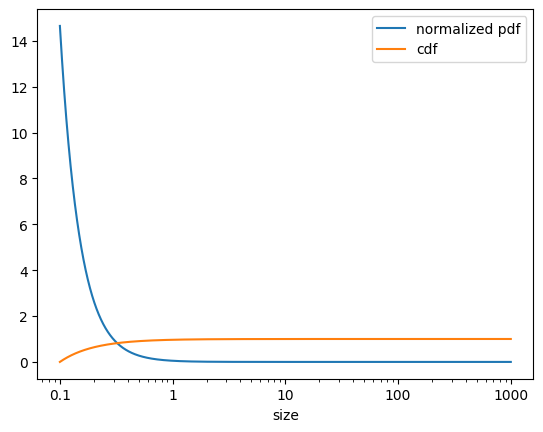

In [12]:
if atmchange==True:
  plt.plot(r_imp_array,pdf,label='normalized pdf')
  plt.plot(r_imp_array,cdf,label='cdf')
  plt.xlabel('size')
  # plt.ylabel('probability')
  plt.xscale('log')
  plt.xticks(ticks=[0.1,1,10,100,1000],labels=[0.1,1,10,100,1000])
  plt.legend()

In [13]:
if atmchange==True and numruns==1:
  np.random.seed(randomseed)
  randomnumbers=np.random.uniform(0,1,numimps)
  randomlychosensizevals=[]

  for randomnum in randomnumbers:
    randomlychosensizevals.append(float(icdf_interp(randomnum)))
    if round(len(randomlychosensizevals)/numimps*100,2)%5==0:
      print(round(len(randomlychosensizevals)/numimps*100,1))#, end='\r')

  seen = set()
  h=0
  for i, e in enumerate(randomlychosensizevals):
      if e in seen:
          h+=1 #randomlychosensizevals[i] = e+np.random.uniform(0.,0.001) #adding a little extra wiggle so there's no repeats, which will mess up a dictionary used in the composite model
      else:
          seen.add(e)
  print(h,'repeats')

  r_imp_array=randomlychosensizevals

In [14]:
if atmchange==True and numruns==1:
  plt.hist(randomlychosensizevals,bins=20)
  # plt.xlim(size_lowerbound,size_upperbound)
  plt.xlabel('size')
  plt.ylabel('number')
  # plt.xscale('log')
  plt.yscale('log')

In [15]:
if atmchange==True and numruns==1:
  plt.scatter(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),randomlychosensizevals,s=3)
  plt.xlabel('array index')
  plt.ylabel('impactor radius (km)')

In [16]:
if atmchange==True and numruns!=1:
  randomseedlist=np.random.uniform(0,1000000,numruns)
  listofr_imp_arrays=[]

  for numrun in range(1,numruns+1):
    np.random.seed(round(randomseedlist[numrun-1]))
    randomnumbers=np.random.uniform(0,1,numimps)
    randomlychosensizevals=[]

    for randomnum in randomnumbers:
      randomlychosensizevals.append(float(icdf_interp(randomnum)))
      if round(len(randomlychosensizevals)/numimps*100,2)%5==0:
        print(round(len(randomlychosensizevals)/numimps*100,1))#, end='\r')

    seen = set()
    h=0
    for i, e in enumerate(randomlychosensizevals):
        if e in seen:
            h+=1 #randomlychosensizevals[i] = e+np.random.uniform(0.,0.001) #adding a little extra wiggle so there's no repeats, which will mess up a dictionary used in the composite model
        else:
            seen.add(e)
    print(h,'repeats for run number',numrun)

    listofr_imp_arrays.append(randomlychosensizevals)

  rimpdict = {}

  for numrun in range(1,numruns+1):
    rimpdict[numrun] = listofr_imp_arrays[numrun-1]

  r_imp_arrays = pd.DataFrame(rimpdict)
  if printdatatables==True: display(r_imp_arrays)

Streaming output truncated to the last 5000 lines.
50.0
50.0
50.0
50.0
50.0
50.0
50.0
50.0
50.0
50.0
50.0
50.0
50.0
50.0
50.0
50.0
50.0
50.0
50.0
50.0
50.0
50.0
50.0
50.0
50.0
50.0
50.0
50.0
50.0
50.0
50.0
50.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
55.0
60.0
60.0
60.0
60.0
60.0
60.0
60.0
60.0
60.0
60.0
60.0
60.0
60.0
60.0
60.0
60.0
60.0
60.0
60.0
60.0
60.0
60.0
60.0
60.0
60.0
60.0
60.0
60.0
60.0
60.0
60.0
60.0
60.0
60.0
60.0
60.0
60.0
60.0
60.0
60.0
60.0
60.0
60.0
60.0
60.0
60.0
60.0
60.0
60.0
60.0
60.0
60.0
60.0
60.0
60.0
60.0
60.0
60.0

In [17]:
#@title savecsv and savepickle functions


def savecsv(modelnickname,losslist,gainlist,deltalist):
  global numrun
  if numruns==1:
    csvnumrun=str(1)
  else:
    csvnumrun=str(numrun)
  if outputdataunits=='mass':
    print('csv output in kg')
    if csvoutput==True or printdatatables==True:
      if atmchange==False:
        data={'Imp Radius (km)':r_imp_array,'Atm M Loss (kg)':losslist,'Atm M Gain (kg)':gainlist,'Delta Atm M (kg)':deltalist}
        df=pd.DataFrame(data, columns = ['Imp Radius (km)', 'Atm M Loss (kg)', 'Atm M Gain (kg)','Delta Atm M (kg)'])
      else:
        data={'Imp Radius (km)':r_imp_array,'Atm M Loss (kg)':losslist,'Atm M Gain (kg)':gainlist,'Running Total Atm M (kg)':deltalist}
        df=pd.DataFrame(data, columns = ['Imp Radius (km)', 'Atm M Loss (kg)', 'Atm M Gain (kg)','Running Total Atm M (kg)'])
    if printdatatables==True:
      display(df)
    if csvoutput==True and csvcompress==False:
      df.to_csv(planet+'_'+modelnickname+'_run'+csvnumrun+'.csv', index=False)
    elif csvoutput==True and csvcompress==True:
      df.to_csv(planet+'_'+modelnickname+'_run'+csvnumrun+'.csv', index=False, compression='zip')
  elif outputdataunits=='pressure':
    print('csv output in Pa')
    if csvoutput==True or printdatatables==True:
      if atmchange==False:
        data={'Imp Radius (km)':r_imp_array,'Atm P Loss (Pa)':losslist,'Atm P Gain (Pa)':gainlist,'Delta Atm P (Pa)':deltalist}
        df=pd.DataFrame(data, columns = ['Imp Radius (km)', 'Atm P Loss (Pa)', 'Atm P Gain (Pa)','Delta Atm P (Pa)'])
      else:
        data={'Imp Radius (km)':r_imp_array,'Atm P Loss (Pa)':losslist,'Atm P Gain (Pa)':gainlist,'Running Total Atm P (Pa)':deltalist}
        df=pd.DataFrame(data, columns = ['Imp Radius (km)', 'Atm P Loss (Pa)', 'Atm P Gain (Pa)','Running Total Atm P (Pa)'])
    if printdatatables==True:
      display(df)
    if csvoutput==True and csvcompress==False:
      df.to_csv(planet+'_'+modelnickname+'_run'+csvnumrun+'.csv', index=False)
    elif csvoutput==True and csvcompress==True:
      df.to_csv(planet+'_'+modelnickname+'_run'+csvnumrun+'.csv', index=False, compression='zip')

def savepickle(modelnickname,losslist,gainlist,deltalist):
  global numrun
  if numruns==1:
    csvnumrun=str(1)
  else:
    csvnumrun=str(numrun)
  if pickleoutput==True:
    if outputdataunits=='mass':
      print('pickle output in kg')
      outFile=open(planet+'_'+modelnickname+'_run'+csvnumrun+'_atm_mass_gains.txt','wb')
      pickle.dump(gainlist, outFile)
      outFile.close()
      outFile=open(planet+'_'+modelnickname+'_run'+csvnumrun+'_atm_mass_losses.txt','wb')
      pickle.dump(losslist, outFile)
      outFile.close()
      if atmchange==False: outFile=open(planet+'_'+modelnickname+'_run'+csvnumrun+'_delta_atm_mass.txt','wb')
      else: outFile=open(planet+'_'+modelnickname+'_run'+csvnumrun+'_running_tot_atm_mass.txt','wb')
      pickle.dump(deltalist, outFile)
      outFile.close()
    elif outputdataunits=='pressure':
      print('pickle output in Pa')
      outFile=open(planet+'_'+modelnickname+'_run'+csvnumrun+'_atm_pressure_gains.txt','wb')
      pickle.dump(gainlist, outFile)
      outFile.close()
      outFile=open(planet+'_'+modelnickname+'_run'+csvnumrun+'_atm_pressure_losses.txt','wb')
      pickle.dump(losslist, outFile)
      outFile.close()
      if atmchange==False: outFile=open(planet+'_'+modelnickname+'_run'+csvnumrun+'_delta_atm_pressure.txt','wb')
      else: outFile=open(planet+'_'+modelnickname+'_run'+csvnumrun+'_running_tot_atm_pressure.txt','wb')
      pickle.dump(deltalist, outFile)
      outFile.close()

getting the mass of the impactor from the radius and density of the impactor

In [18]:
#@title does the impactor hit the surface? NOT CURRENTLY INCORPORATED OR USED

def min_r_imp_for_impact(P_atm,angle=90,g=gravity,rho_imp=rho_imp):
  return (3*P_atm)/(4*g*rho_imp)*np.sin(angle*np.pi/180)

def check_for_impact(r_imp,P_atm,angle=90,g=gravity,rho_imp=rho_imp):
  if r_imp<min_r_imp_for_impact(P_atm,angle=90,g=gravity,rho_imp=rho_imp):
    hits=False
  else:
    hits=True
  return hits

In [19]:
#@title M_imp function & pressure from atmospheric mass functions & drag equation (drag not currently incorporated or used)

def M_imp(rho_imp,r_imp):
  return 4/3*np.pi*r_imp**3*rho_imp

def atmmass_to_surfacepressure(radius,atmmass,gravity): #mika here something is wrong here or in the constants. doesn't give the right pressure for the mass
  return atmmass*gravity/(4*np.pi*(radius)**2)*conversionfactor #conversion factor goes from kg/(km s^2) for pressure units to kg/(m s^2)=Pa

def pressurearray(mass_array,radiusoftarget,gravityoftarget):
  Parray=[]
  for m in mass_array:
    Parray.append(atmmass_to_surfacepressure(radiusoftarget,m,gravityoftarget))
  return Parray

def drag(r_imp,v_imp):
  m_imp=M_imp(rho_imp,r_imp)
  D=2*r_imp
  alpha=rho_atm/rho_imp*(H/D+8*H**2/(3*D**2)*(rho_atm/rho_imp)**0.5+8*H**3/D**3*rho_atm/rho_imp) #from svetsov 2000 (see caitlin preprint eqns 19 & 20)
  newv_imp=v_imp*np.exp(-alpha*c_d/2)
  projectedarea=np.pi*r_imp**2 #projected area is a circle
  #terminalvelocity=((2*m_imp*gravity)/(rho_imp*projectedarea*c_d))**0.5 #i don't think the min should be v_term. v_term is typically the max for a free falling obj
  # print(terminalvelocity)
  #if newv_imp<terminalvelocity: #mika here i feel like the lowest velocity it can be is terminal velocity
    #newv_imp=terminalvelocity
  return newv_imp

#testing pressure eqn
# print(r_planet)
# print(mass_atm)
# print(gravity)
# print(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity))

In [20]:
#@title cont

new_vimp_array=[]
for r_imp in r_imp_array:
  new_vimp_array.append(drag(r_imp,v_imp))

([<matplotlib.axis.XTick at 0x78d1af38cf40>,
 [Text(0.1, 0, '0.1'),
  Text(1.0, 0, '1'),
  Text(10.0, 0, '10'),
  Text(100.0, 0, '100'),
  Text(1000.0, 0, '1000')])

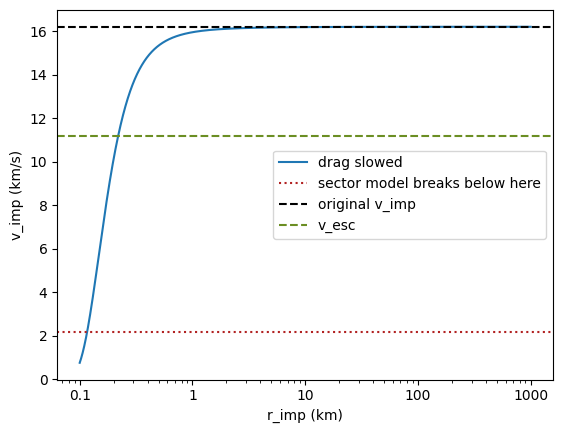

In [21]:
#@title cont
plt.plot(r_imp_array,new_vimp_array,label='drag slowed')
plt.axhline(v_esc/5.1,color='firebrick',linestyle='dotted',label='sector model breaks below here')
plt.xscale('log')
plt.axhline(v_imp,color='black',linestyle='dashed',label='original v_imp')
plt.axhline(v_esc,color='olivedrab',linestyle='dashed',label='v_esc')
plt.legend()
plt.xlabel('r_imp (km)')
plt.ylabel('v_imp (km/s)')
plt.xticks(ticks=[0.1,1,10,100,1000],labels=[0.1,1,10,100,1000])

Shuvalov definition

In [22]:
#@title shuvalov functions

#first define shuvalov as per https://colab.research.google.com/drive/1M5W_tYoOlz8Ob_4s5RLXo5EjVSIdd88p?usp=sharing
#if we change that file, we'll need to change this one too

def shu_m_atm_loss(chi_A,m_imp,v_imp,v_esc):
  return chi_A*m_imp*(v_imp**2-v_esc**2)/v_esc**2

def shu_chi_a(Xi):
  return 10**(-6.375+5.239*np.log10(Xi)-2.121*np.log10(Xi)**2+0.397*np.log10(Xi)**3-0.037*np.log10(Xi)**4+0.0013*np.log10(Xi)**5)

def shu_xi(r_imp,H,rho_imp,rho_atm,v_imp,v_esc,rho_tar):
  D=r_imp*2
  return (D/H)**3*(rho_imp*(v_imp**2-v_esc**2)*rho_tar)/(rho_atm*v_esc**2*(rho_tar+rho_imp))

def shu_m_atm_gain(r_imp,rho_imp,Chi_imp):
  vol_imp=4/3*np.pi*r_imp**3
  return vol_imp*rho_imp*(1-Chi_imp)

def shu_chi_imp(rho_tar,rho_imp,v_imp,v_esc,Xi):
  # print(rho_tar,rho_imp,v_imp,v_esc,Xi)
  # print((np.log10(Xi)-1))
  comparisonvalue=0.07*(rho_tar/rho_imp)*(v_imp/v_esc)*(np.log10(Xi)-1)
  if 1.<comparisonvalue:
    returnval=1.
  else:
    returnval=comparisonvalue
  # print('which is bigger, 1 or',comparisonvalue,'?')
  # print(returnval)
  return returnval

def shuatmchange(r_imp_array,lossprint=False,gainprint=False):
  m_loss,m_gain,m_tot=[],[],[]
  for r_imp in r_imp_array:
    if len(m_loss)==0:
      new_atm_m=mass_atm
    else:
      new_atm_m=m_tot[-1]
    new_rho_atm=new_atm_m/presentday_atm_m*rho_atm

    Xi=shu_xi(r_imp,H,rho_imp,new_rho_atm,v_imp,v_esc,rho_tar)
    chi_A=shu_chi_a(Xi)
    m_Imp=M_imp(rho_imp,r_imp)
    M_loss=shu_m_atm_loss(chi_A,m_Imp,v_imp,v_esc)
    if lossprint==True:
      print('xi =',Xi)
      print('chi_a =',chi_A)
      print('m_imp =',m_Imp)
      print('atm m loss =',M_loss)
    m_loss.append(M_loss)

    Xi=shu_xi(r_imp,H,rho_imp,rho_atm,v_imp,v_esc,rho_tar)
    Chi_imp=shu_chi_imp(rho_tar,rho_imp,v_imp,v_esc,Xi)
    M_gain=shu_m_atm_gain(r_imp,rho_imp,Chi_imp)
    if gainprint==True:
      print('xi =',Xi)
      print('Chi_imp =',Chi_imp)
      print('atm m gain =',M_gain)
    m_gain.append(M_gain)

    newtotalmass=new_atm_m+M_gain-M_loss
    if newtotalmass<0:
      m_tot.append(0.)
    else:
      m_tot.append(newtotalmass)

  return m_loss,m_gain,m_tot

def shuloss(r_imp_array,lossprint=False): #gives the mass loss from the atm to space in kg
  m_loss=[]
  for r_imp in r_imp_array:
    Xi=shu_xi(r_imp,H,rho_imp,rho_atm,v_imp,v_esc,rho_tar)
    chi_A=shu_chi_a(Xi)
    m_Imp=M_imp(rho_imp,r_imp)
    M_loss=shu_m_atm_loss(chi_A,m_Imp,v_imp,v_esc)
    if lossprint==True:
      print('xi =',Xi)
      print('chi_a =',chi_A)
      print('m_imp =',m_Imp)
      print('atm m loss =',M_loss)
    m_loss.append(M_loss)
  return m_loss

def shugain(r_imp_array,gainprint=False): #gives the mass gain to the atm in kg
  m_gain=[]
  for r_imp in r_imp_array:
    Xi=shu_xi(r_imp,H,rho_imp,rho_atm,v_imp,v_esc,rho_tar)
    Chi_imp=shu_chi_imp(rho_tar,rho_imp,v_imp,v_esc,Xi)
    M_gain=shu_m_atm_gain(r_imp,rho_imp,Chi_imp)
    if gainprint==True:
      print('xi =',Xi)
      print('Chi_imp =',Chi_imp)
      print('atm m gain =',M_gain)
    m_gain.append(M_gain)

  return m_gain

pham definition

In [23]:
#@title pham functions

#defining pham as per Julia Johnston's spring 2023 work with some modifications

def pham_tan_plane_mass(mass_atm,scale_height):
  m_tan=mass_atm*scale_height/(2*planet_radius)
  return m_tan

def pham_crit_mass(n,m_tan):
  m_crit=n*m_tan
  return m_crit

def pham_m_atm_loss(m_imp,m_crit,m_tan):
  if m_imp<m_crit:
    m_loss=0.
  else:
    m_loss=m_tan*f_vel*f_obl
  return m_loss

def pham_m_atm_gain(m_imp,m_crit,y_imp=y_imp,f_vap=f_vap,papereqn=False,g_vap=0.42):
  if m_imp<m_crit:
    m_gain=m_imp*y_imp*f_vap
  else:
    if papereqn==False: #we don't like the eqn given in pham for the mass delivered if the imp mass> critical mass. we think it should be 0 in that case
      m_gain=0.
    else:
      m_gain=(1.-f_vel*f_obl)*m_imp*y_imp*g_vap
  return m_gain

def phamloss(r_imp_array,n,mass_atm,scale_height=H,rho_imp=rho_imp,planet_radius=planet_radius,f_vel=f_vel,f_obl=f_obl,lossprint=False):
  m_loss=[]
  for r_imp in r_imp_array:
    m_imp=M_imp(rho_imp,r_imp)
    m_tan=pham_tan_plane_mass(mass_atm,scale_height)
    m_crit=pham_crit_mass(n,m_tan)
    M_loss=pham_m_atm_loss(m_imp,m_crit,m_tan)
    if lossprint==True:
      print('m_imp =',m_imp)
      print('m_crit =',m_crit)
      print('m_tan =',m_tan)
      print('f_vel=',f_vel)
      print('f_obl=',f_obl)
      print('atm m loss =',M_loss)
    m_loss.append(M_loss)
  return m_loss

def phamgain(r_imp_array,mass_atm,n,scale_height=H,planet_radius=planet_radius,y_imp=y_imp,f_vap=f_vap,gainprint=False,papereqn=False):
  m_gain=[]
  for r_imp in r_imp_array:
    m_imp=M_imp(rho_imp,r_imp)
    m_tan=pham_tan_plane_mass(mass_atm,scale_height)
    m_crit=pham_crit_mass(n,m_tan)
    M_gain=pham_m_atm_gain(m_imp,m_crit,papereqn=papereqn)
    if gainprint==True:
      print('m_imp =',m_imp)
      print('m_crit =',m_crit)
      print('m_tan =',m_tan)
      print('y_imp=',y_imp)
      print('f_vap=',f_vap)
      print('atm m gain =',M_gain)
    m_gain.append(M_gain)
  return m_gain

def phamatmchange(r_imp_array,papereqn=False):
  m_loss,m_gain,m_tot=[],[],[]
  for r_imp in r_imp_array:
    if len(m_loss)==0:
      new_atm_m=mass_atm
    else:
      new_atm_m=m_tot[-1]

    m_imp=M_imp(rho_imp,r_imp)
    m_tan=pham_tan_plane_mass(new_atm_m,H)
    m_crit=pham_crit_mass(n,m_tan)
    M_loss=pham_m_atm_loss(m_imp,m_crit,m_tan)
    m_loss.append(M_loss)

    M_gain=pham_m_atm_gain(m_imp,m_crit,papereqn=papereqn)
    m_gain.append(M_gain)

    newtotalmass=new_atm_m+M_gain-M_loss
    if newtotalmass<0:
      m_tot.append(0.)
    else:
      m_tot.append(newtotalmass)

  return m_loss,m_gain,m_tot

genda & abe definition

In [24]:
#@title Genda & Abe functions

#using eqn 11 from de Niem 2012 for the loss

def ga_m_atm_loss(Z,vimp,vesc,rimp,targetscaleheight,rho_atm):
  impdiam=2*rimp
  if enhancementfactorcheck==True:
    return ((2**(2/3)*Z*(4*(vimp/vesc)**(1-2/Z)-4**(2/Z)))/(12*(Z-2))*(np.pi*impdiam**2*targetscaleheight*rho_atm)*(vimp/vesc)**2/Z)*enhancementfactor
  else:
    return (2**(2/3)*Z*(4*(vimp/vesc)**(1-2/Z)-4**(2/Z)))/(12*(Z-2))*(np.pi*impdiam**2*targetscaleheight*rho_atm)*(vimp/vesc)**2/Z

def galoss(r_imp_array,Z,vimp,vesc,targetscaleheight,rho_atm):
  m_loss=[]
  for r_imp in r_imp_array:
    M_loss=ga_m_atm_loss(Z,vimp,vesc,r_imp,targetscaleheight,rho_atm)
    m_loss.append(M_loss)
  return m_loss

def gagain(r_imp_array,mass_atm,scale_height,planet_radius,n,y_imp,f_vap,papereqn=False):
  if ogphamgaineqn==True:
    papereqn=True
  m_gain=[]
  for r_imp in r_imp_array:
    m_imp=M_imp(rho_imp,r_imp)
    m_tan=pham_tan_plane_mass(mass_atm,scale_height)
    m_crit=pham_crit_mass(n,m_tan)
    M_gain=pham_m_atm_gain(m_imp,m_crit,papereqn=papereqn)
    m_gain.append(M_gain)
  return m_gain

def gaatmchange(r_imp_array,modelforgain,papereqn=ogphamgaineqn,n=None):
  m_loss,m_gain,m_tot=[],[],[]
  for r_imp in r_imp_array:
    if len(m_loss)==0:
      new_atm_m=mass_atm
    else:
      new_atm_m=m_tot[-1]

    new_rho_atm=new_atm_m/presentday_atm_m*rho_atm
    M_loss=ga_m_atm_loss(Z,v_imp,v_esc,r_imp,H,new_rho_atm)
    m_loss.append(M_loss)

    if modelforgain=='pham':
      m_imp=M_imp(new_rho_atm,r_imp)
      m_tan=pham_tan_plane_mass(new_atm_m,H)
      m_crit=pham_crit_mass(n,m_tan)
      M_gain=pham_m_atm_gain(m_imp,m_crit,papereqn=papereqn)
      m_gain.append(M_gain)
    elif modelforgain=='sec':
      M_gain=sec_m_gain(M_imp(rho_imp,r_imp),y_imp,v_imp,r_imp)
      m_gain.append(M_gain)
    elif modelforgain=='simp':
      M_gain=simp_m_atm_gain(rho_imp,r_imp,y_imp)
      m_gain.append(M_gain)
    else:
      print('gain model',modelforgain,'not recognized')
      print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')

    newtotalmass=new_atm_m+M_gain-M_loss
    if newtotalmass<0:
      m_tot.append(0.)
    else:
      m_tot.append(newtotalmass)

  return m_loss,m_gain,m_tot

svetsov 2000 definition

In [25]:
#@title Svetsov 2000 functions

#using eqns 11 thru 15 from Svetsov 2000

def integralquotient(x): #only works for k=5, which is the value suggested by svestov 2007
  return (63*x**11-385*x**9+990*x**7-1386*x**5+1155*x**3-693*x+256)/256

def svet_m_atm_loss(r_imp, rho_imp, Rho_atm,H,v_esc,v_imp,gamma,c_d):
  m_Imp=M_imp(rho_imp,r_imp)
  m_expandinglayer_over_m_imp=Rho_atm/rho_imp*(H/(2*r_imp)+2*H**2/(3*r_imp**2)*(Rho_atm/rho_imp)**0.5+H**3*Rho_atm/(r_imp**3*rho_imp))
  m_loss=m_Imp*m_expandinglayer_over_m_imp*integralquotient(v_esc/v_imp*((gamma-1)/(4*gamma))**0.5*np.exp(c_d/2*m_expandinglayer_over_m_imp))
  if enhancementfactorcheck==True:
    returnval= m_loss*enhancementfactor
  else:
    returnval= m_loss
  if np.isnan(returnval):
    returnval=1E308
  if fixsvetcheck==True:
    #if the starting atmosphere is more than the value we get from the equation for our specific impactor radius, we just set the resulting loss to 0
    dangeratmP=2349446.197403981*r_imp**1.4610371489984268
    new_atm_m=Rho_atm/rho_atm*presentday_atm_m
    if pressurearray([new_atm_m],r_planet,gravity)[0]>dangeratmP:
      returnval=0.
  return returnval

def svetloss(r_imp_array, rho_imp, rho_atm,H,v_esc,v_imp,gamma,c_d): #not using pham here bc this model is only for small imps so it wouldn't matter
  m_loss=[]
  for r_imp in r_imp_array:
    M_loss=svet_m_atm_loss(r_imp, rho_imp, rho_atm,H,v_esc,v_imp,gamma,c_d)
    m_loss.append(M_loss)
  return m_loss

def svet_m_atm_gain(rho_imp,r_imp,y_imp): #not using pham here bc this model is only for small imps so it wouldn't matter
  m_imp=M_imp(rho_imp,r_imp)
  return y_imp*m_imp

def svetgain(r_imp_array,rho_imp,y_imp): #not using pham here bc this model is only for small imps so it wouldn't matter
  m_gain=[]
  for r_imp in r_imp_array:
    M_gain=svet_m_atm_gain(rho_imp,r_imp,y_imp)
    m_gain.append(M_gain)
  return m_gain

def svetatmchange(r_imp_array,modelforgain,papereqn=ogphamgaineqn,n=None):
  m_loss,m_gain,m_tot=[],[],[]
  for r_imp in r_imp_array:
    if len(m_loss)==0:
      new_atm_m=mass_atm
    else:
      new_atm_m=m_tot[-1]

    new_rho_atm=new_atm_m/presentday_atm_m*rho_atm
    M_loss=svet_m_atm_loss(r_imp, rho_imp, new_rho_atm, H, v_esc, v_imp, gamma, c_d)
    m_loss.append(M_loss)

    if modelforgain=='pham':
      m_imp=M_imp(new_rho_atm,r_imp)
      m_tan=pham_tan_plane_mass(new_atm_m,H)
      m_crit=pham_crit_mass(n,m_tan)
      M_gain=pham_m_atm_gain(m_imp,m_crit,papereqn=papereqn)
      m_gain.append(M_gain)
    elif modelforgain=='sec':
      M_gain=sec_m_gain(M_imp(rho_imp,r_imp),y_imp,v_imp,r_imp)
      m_gain.append(M_gain)
    elif modelforgain=='simp':
      M_gain=simp_m_atm_gain(rho_imp,r_imp,y_imp)
      m_gain.append(M_gain)
    else:
      print('gain model',modelforgain,'not recognized')
      print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')

    newtotalmass=new_atm_m+M_gain-M_loss
    if newtotalmass<0.:
      m_tot.append(0.)
    else:
      m_tot.append(newtotalmass)
  return m_loss,m_gain,m_tot

svetsov 2007 definition

In [26]:
#@title Svetsov 2007 functions
def integralquotient(parens):
  return (63*parens**11-385*parens**9+990*parens**7-1386*parens**5+1155*parens**3-693*parens+256)/256

def psi_1(r_imp,v_imp,rho_atm,rho_imp,scale_height,current_v_esc,e_0):
  D=2*r_imp
  parens=C2*current_v_esc/v_imp*np.exp(C3*(scale_height*e_0**0.5/(D*v_imp))**C4*(v_imp/current_v_esc)**C5)
  Psi1=2*C1*rho_atm/rho_imp*(scale_height/D+8*scale_height**2/(3*D**2)*(rho_atm/rho_imp)**0.5+(8*scale_height**3*rho_atm)/(D**3*rho_imp))*integralquotient(parens)
  return Psi1

def psi_2(r_imp,v_imp,current_v_esc,rho_imp,scale_height,rho_atm):
  D=2*r_imp
  parens=0.9*current_v_esc/v_imp
  num=(zeta_v(v_imp,current_v_esc)+10**-3*integralquotient(parens))*D**4*rho_imp**0.5
  denom=(2*scale_height)**4*rho_atm**0.5
  tancomponent=np.arctan2(num,denom)
  Psi2=(12*rho_atm*(1.5625*D**2*scale_height+3.75*D*scale_height**2+4.5*H**3))/(np.pi*rho_imp*D**3)*tancomponent
  return Psi2

def svet07_m_atm_loss(r_imp,v_imp,rho_atm,rho_imp,scale_height,current_v_esc,e_0):
  m_imp=M_imp(rho_imp,r_imp)
  return m_imp*(psi_1(r_imp,v_imp,rho_atm,rho_imp,scale_height,current_v_esc,e_0)+psi_2(r_imp,v_imp,current_v_esc,rho_imp,scale_height,rho_atm))*enhancementfactor #last factor is from de Niem, is a correction factor suggested by svet07 to acount for oblique impacts
  #it's the integral of (1+2sin(2 alpha))^2 over impact angle distrib sin(2alpha) d alpha over the interval (0,pi/2)

def svet07loss(r_imp_array,v_imp,rho_atm,rho_imp,scale_height,current_v_esc,e_0):
  m_loss=[]
  for r_imp in r_imp_array:
    M_loss=svet07_m_atm_loss(r_imp,v_imp,rho_atm,rho_imp,scale_height,current_v_esc,e_0)
    m_loss.append(M_loss)
  return m_loss

def zeta_v(v_imp,current_v_esc):
  return C6*(v_imp/current_v_esc-C7)**C8

def zeta(r_imp,current_v_esc,v_imp,scale_height,rho_imp,rho_atm):
  D=r_imp*2
  Zeta=psi_1(0.35*D/2,v_imp,rho_atm,rho_imp,scale_height,current_v_esc,e_0)/svetdelta*(C7*current_v_esc/v_imp)**0.25+zeta_v(v_imp,current_v_esc)*2/np.pi*np.arctan2(zeta_v(v_imp,current_v_esc)**4*D**1.2*rho_imp**0.5,2*scale_height**1.2*rho_atm**0.5)
  return Zeta

def svet07_m_atm_gain(r_imp,rho_imp,y_imp,current_v_esc,v_imp,scale_height,rho_atm):
  m_imp=M_imp(rho_imp,r_imp)
  #some amount of impactor gets ablated away
  remaining_m_imp=m_imp*(1-zeta(r_imp,current_v_esc,v_imp,scale_height,rho_imp,rho_atm))
  if fixsvet07check==True and y_imp*remaining_m_imp<0:
    return 0.
  else:
    return y_imp*remaining_m_imp

def svet07gain(r_imp_array,rho_imp,y_imp,current_v_esc,v_imp,scale_height,rho_atm):
  m_gain=[]
  for r_imp in r_imp_array:
    M_gain=svet07_m_atm_gain(r_imp,rho_imp,y_imp,current_v_esc,v_imp,scale_height,rho_atm) #mika here might need to recalc current v esc at each step
    m_gain.append(M_gain)
  return m_gain

def svet07atmchange(r_imp_array):
  m_loss,m_gain,m_tot=[],[],[]
  for r_imp in r_imp_array:
    if len(m_loss)==0:
      new_atm_m=mass_atm
    else:
      new_atm_m=m_tot[-1]
    new_rho_atm=new_atm_m/presentday_atm_m*rho_atm #mika here this is prolly wrong. keeping volume const which is incorrect

    M_loss=svet07_m_atm_loss(r_imp,v_imp,new_rho_atm,rho_imp,H,current_v_esc,e_0)
    m_loss.append(M_loss)

    M_gain=svet07_m_atm_gain(r_imp,rho_imp,y_imp,current_v_esc,v_imp,H,new_rho_atm)
    m_gain.append(M_gain)

    newtotalmass=new_atm_m+M_gain-M_loss
    if newtotalmass<0:
      m_tot.append(0.)
    else:
      m_tot.append(newtotalmass)

  return m_loss,m_gain,m_tot

sector model functions (vickery and melosj 1990)

In [27]:
#@title Sector Model Functions

def integrand(xi, k):
    return xi**2*(1-xi**2)**k

def sectorzeta(v_imp):
  k=1/(specificentropy-1)
  C=2/scipy.special.beta(3/2,k+1)
  v_inf=v_imp*np.sqrt(4*gamma/(gamma-1))
  x=v_esc/v_inf
  zeta=C*scipy.integrate.quad(integrand, x, 1, args=(k))[0]
  return zeta

def sec_m_gain(m_imp, y_imp, v_imp, r_imp):
  if dragcheck==True:
    v_imp=drag(r_imp,v_imp)
  return (1-sectorzeta(v_imp))*y_imp*m_imp

def secgain(r_imp_array):
  m_gain=[]
  for r_imp in r_imp_array:
    M_gain=sec_m_gain(M_imp(rho_imp,r_imp), y_imp, v_imp, r_imp)
    m_gain.append(M_gain)
  return m_gain

simple model gain function

In [28]:
#@title Simple Gain Model (mass of impactor times volatile content fraction)

def simp_m_atm_gain(rho_imp,r_imp,y_imp):
  m_imp=M_imp(rho_imp,r_imp)
  return y_imp*m_imp

def simpgain(r_imp_array):
  m_gain=[]
  for r_imp in r_imp_array:
    M_gain=simp_m_atm_gain(rho_imp,r_imp,y_imp)
    m_gain.append(M_gain)
  return m_gain

composite model

In [29]:
#@title composite model functions
compdict={}
comp_M_loss=[]
comp_M_gain=[]

if 'svet' in mods.Nickname.values:
  svetindex=int(mods[mods['Nickname'] == 'svet'].index[0])
  svetmodelforgain=str(mods['Gain Model'][svetindex])
if 'ga' in mods.Nickname.values:
  gaindex=int(mods[mods['Nickname'] == 'ga'].index[0])
  gamodelforgain=str(mods['Gain Model'][gaindex])

def compsetup():
  global comp_M_loss; global comp_M_gain; global sizeregimes; global compdict; global r_imp_array
  compdict={}
  comp_M_loss=[]
  comp_M_gain=[]

  i=0
  for r_imp in r_imp_array:
    compdict[i]=[r_imp,[]]
    # print('testing imp radius',round(r_imp,3))
    for model in sizeregimes:
      if sizeregimes[model][0]<=r_imp<sizeregimes[model][1]:
        # print(sizeregimes[model][0],'<=',round(r_imp,3),'<',sizeregimes[model][1],'thus assign impactor',model)
        compdict[i][1].append(model)
    i+=1
  # print(compdict)

def comprun(papereqn=False):
  global comp_M_loss; global comp_M_gain; global comp_P_gain; global comp_P_loss; global comp_delta_M; global comp_delta_P; global compdict
  if ogphamgaineqn==True:
    papereqn=True
  scale_height=H
  # print(compdict)
  for i in compdict:
    r_imp=compdict[i][0]
    # print('rimp=',r_imp)
    # print(compdict[i])
    gain=[]
    loss=[]
    m_imp=M_imp(rho_imp,r_imp)
    for model in compdict[i][1]:
      if model=='svet':
        if svetmodelforgain=='pham':
          m_imp=M_imp(rho_atm,r_imp)
          m_tan=pham_tan_plane_mass(mass_atm,H)
          m_crit=pham_crit_mass(n,m_tan)
          M_gain=pham_m_atm_gain(m_imp,m_crit,papereqn=papereqn)
          gain.append(M_gain)
        elif svetmodelforgain=='sec':
          M_gain=sec_m_gain(M_imp(rho_imp,r_imp),y_imp,v_imp,r_imp)
          gain.append(M_gain)
        elif svetmodelforgain=='simp':
          M_gain=simp_m_atm_gain(rho_imp,r_imp,y_imp)
          gain.append(M_gain)
        else:
          print('gain model',svetmodelforgain,'not recognized')
          print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')
        loss.append(svet_m_atm_loss(r_imp, rho_imp, rho_atm,H,v_esc,v_imp,gamma,c_d))
      elif model=='svet07':
        gain.append(svet07_m_atm_gain(r_imp,rho_imp,y_imp,current_v_esc,v_imp,scale_height,rho_atm))
        loss.append(svet07_m_atm_loss(r_imp,v_imp,rho_atm,rho_imp,scale_height,current_v_esc,e_0))
      elif model=='pham10':
        n=10
        m_tan=pham_tan_plane_mass(mass_atm,scale_height)
        m_crit=pham_crit_mass(n,m_tan)
        gain.append(pham_m_atm_gain(m_imp,m_crit,papereqn=papereqn))
        loss.append(pham_m_atm_loss(m_imp,m_crit,m_tan))
      elif model=='pham2400':
        n=2400
        m_tan=pham_tan_plane_mass(mass_atm,scale_height)
        m_crit=pham_crit_mass(n,m_tan)
        gain.append(pham_m_atm_gain(m_imp,m_crit,papereqn=papereqn))
        loss.append(pham_m_atm_loss(m_imp,m_crit,m_tan))
      elif model=='shu':
        Xi=shu_xi(r_imp,H,rho_imp,rho_atm,v_imp,v_esc,rho_tar)
        chi_A=shu_chi_a(Xi)
        Chi_imp=shu_chi_imp(rho_tar,rho_imp,v_imp,v_esc,Xi)
        gain.append(shu_m_atm_loss(chi_A,m_imp,v_imp,v_esc))
        loss.append(shu_m_atm_gain(r_imp,rho_imp,Chi_imp))
      elif model=='ga':
        if gamodelforgain=='pham':
          m_imp=M_imp(rho_atm,r_imp)
          m_tan=pham_tan_plane_mass(mass_atm,H)
          m_crit=pham_crit_mass(n,m_tan)
          M_gain=pham_m_atm_gain(m_imp,m_crit,papereqn=papereqn)
          gain.append(M_gain)
        elif gamodelforgain=='sec':
          M_gain=sec_m_gain(M_imp(rho_imp,r_imp),y_imp,v_imp,r_imp)
          gain.append(M_gain)
        elif gamodelforgain=='simp':
          M_gain=simp_m_atm_gain(rho_imp,r_imp,y_imp)
          gain.append(M_gain)
        else:
          print('gain model',gamodelforgain,'not recognized')
          print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')
        loss.append(ga_m_atm_loss(Z,v_imp,v_esc,r_imp,H,rho_atm))
      else:
        print('model nickname',model,'not recognized')
        print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')
    # print('gain=',gain)
    # print('loss=',loss)
    comp_M_loss.append(np.average(loss))
    comp_M_gain.append(np.average(gain))
  comp_delta_M=np.asarray(comp_M_gain)-np.asarray(comp_M_loss)
  # print(comp_M_loss)
  # print(comp_M_gain)
  # print(comp_delta_M)
  if outputdataunits=='pressure':
    comp_P_loss=pressurearray(comp_M_loss,r_planet,gravity)
    comp_P_gain=pressurearray(comp_M_gain,r_planet,gravity)
    comp_delta_P=pressurearray(comp_delta_M,r_planet,gravity)
    savecsv('comp',comp_P_loss,comp_P_gain,comp_delta_P)
    savepickle('comp',comp_P_loss,comp_P_gain,comp_delta_P)
  elif outputdataunits=='mass':
    savecsv('comp',comp_M_loss,comp_M_gain,comp_delta_M)
    savepickle('comp',comp_M_loss,comp_M_gain,comp_delta_M)
  else:
    print('output units',outputdataunits,'not recognized')
    print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')
  #mika here if change models will need to alter these too


def compatmchangerun(papereqn=False):
  global comp_M_loss; global comp_M_gain; global comp_P_gain; global comp_P_loss; global comp_delta_M; global comp_delta_P; global compdict
  print(list(compdict.items())[0:10])
  print('length of compdict',len(compdict))

  m_tot=[]
  if ogphamgaineqn==True:
    papereqn=True
  scale_height=H

  for i in compdict:
    r_imp=compdict[i][0]
    if len(m_tot)==0:
      new_atm_m=mass_atm
    else:
      new_atm_m=m_tot[-1]
    new_rho_atm=new_atm_m/presentday_atm_m*rho_atm
    if new_rho_atm==0:
      new_rho_atm=0.00000000000000000000000000000000000001

    gain=[]
    loss=[]
    m_imp=M_imp(rho_imp,r_imp)


#have the current atm mass stored as new_atm_m
    for model in compdict[i][1]:
      if model=='svet':
        if svetmodelforgain=='pham':
          m_imp=M_imp(new_rho_atm,r_imp)
          m_tan=pham_tan_plane_mass(new_atm_m,H)
          m_crit=pham_crit_mass(n,m_tan)
          M_gain=pham_m_atm_gain(m_imp,m_crit,papereqn=papereqn)
          gain.append(M_gain)
        elif svetmodelforgain=='sec':
          M_gain=sec_m_gain(M_imp(rho_imp,r_imp),y_imp,v_imp,r_imp)
          gain.append(M_gain)
        elif svetmodelforgain=='simp':
          M_gain=simp_m_atm_gain(rho_imp,r_imp,y_imp)
          gain.append(M_gain)
        else:
          print('gain model',svetmodelforgain,'not recognized')
          print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')
        loss.append(svet_m_atm_loss(r_imp, rho_imp, new_rho_atm, H, v_esc, v_imp, gamma, c_d))
      elif model=='svet07':
        gain.append(svet07_m_atm_gain(r_imp,rho_imp,y_imp,current_v_esc,v_imp,H,new_rho_atm))
        loss.append(svet07_m_atm_loss(r_imp,v_imp,new_rho_atm,rho_imp,H,current_v_esc,e_0))
      elif model=='pham10':
        n=10
        m_tan=pham_tan_plane_mass(new_atm_m,scale_height)
        m_crit=pham_crit_mass(n,m_tan)
        gain.append(pham_m_atm_gain(m_imp,m_crit,papereqn=papereqn))
        loss.append(pham_m_atm_loss(m_imp,m_crit,m_tan))
      elif model=='pham2400':
        n=2400
        m_tan=pham_tan_plane_mass(new_atm_m,scale_height)
        m_crit=pham_crit_mass(n,m_tan)
        gain.append(pham_m_atm_gain(m_imp,m_crit,papereqn=papereqn))
        loss.append(pham_m_atm_loss(m_imp,m_crit,m_tan))
      elif model=='shu':
        Xi=shu_xi(r_imp,H,rho_imp,new_rho_atm,v_imp,v_esc,rho_tar)
        chi_A=shu_chi_a(Xi)
        Chi_imp=shu_chi_imp(rho_tar,rho_imp,v_imp,v_esc,Xi)
        gain.append(shu_m_atm_loss(chi_A,m_imp,v_imp,v_esc))
        loss.append(shu_m_atm_gain(r_imp,rho_imp,Chi_imp))
      elif model=='ga':
        if gamodelforgain=='pham':
          m_imp=M_imp(new_rho_atm,r_imp)
          m_tan=pham_tan_plane_mass(new_atm_m,H)
          m_crit=pham_crit_mass(n,m_tan)
          M_gain=pham_m_atm_gain(m_imp,m_crit,papereqn=papereqn)
          gain.append(M_gain)
        elif gamodelforgain=='sec':
          M_gain=sec_m_gain(M_imp(rho_imp,r_imp),y_imp,v_imp,r_imp)
          gain.append(M_gain)
        elif gamodelforgain=='simp':
          M_gain=simp_m_atm_gain(rho_imp,r_imp,y_imp)
          gain.append(M_gain)
        else:
          print('gain model',gamodelforgain,'not recognized')
          print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')
        loss.append(ga_m_atm_loss(Z,v_imp,v_esc,r_imp,H,new_rho_atm))
      else:
        print('model nickname',model,'not recognized')
        print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')

    comp_M_loss.append(np.average(loss))
    comp_M_gain.append(np.average(gain))

    newtotalmass=new_atm_m+np.average(gain)-np.average(loss)
    if newtotalmass<0:
      m_tot.append(0.)
    else:
      m_tot.append(newtotalmass)


  comp_delta_M=m_tot
  print(len(comp_M_loss),len(comp_M_gain),len(comp_delta_M))

  if outputdataunits=='pressure':
    comp_P_loss=pressurearray(comp_M_loss,r_planet,gravity)
    comp_P_gain=pressurearray(comp_M_gain,r_planet,gravity)
    comp_delta_P=pressurearray(comp_delta_M,r_planet,gravity)
    # print(len(comp_P_loss),len(comp_P_gain),len(comp_delta_P))
    savecsv('comp',comp_P_loss,comp_P_gain,comp_delta_P)
    savepickle('comp',comp_P_loss,comp_P_gain,comp_delta_P)
  elif outputdataunits=='mass':
    savecsv('comp',comp_M_loss,comp_M_gain,comp_delta_M)
    savepickle('comp',comp_M_loss,comp_M_gain,comp_delta_M)
  else:
    print('output units',outputdataunits,'not recognized')
    print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')
  #mika here if change models will need to alter these too

In [30]:
#@title individual model running functions
def pham10run():
  global n;global j;global shu_M_loss;global shu_M_gain;global pham10_M_loss;global pham10_M_gain;global pham2400_M_loss;global pham2400_M_gain;global pham10_corresponding_crit_imp_r;global pham2400_corresponding_crit_imp_r;global pham10_delta_M;global pham2400_delta_M;global shu_delta_M;global ga_M_loss;global ga_M_gain;global ga_delta_M;global ga_corresponding_crit_imp_r;global svet_M_loss;global svet_M_gain;global svet_delta_M;global svet07_M_loss;global svet07_M_gain;global svet07_delta_M;global shu_P_loss;global shu_P_gain;global pham10_P_loss;global pham10_P_gain;global pham2400_P_loss;global pham2400_P_gain;global pham10_delta_P;global pham2400_delta_P;global shu_delta_P;global ga_P_loss;global ga_P_gain;global ga_delta_P;global ga_m_crit;global svet_P_loss;global svet_P_gain;global svet_delta_P;global svet07_P_loss;global svet07_P_gain;global svet07_delta_P

  if atmchange==True:
    if ogphamgaineqn==True:
      pham10_M_loss,pham10_M_gain,pham10_delta_M=phamatmchange(r_imp_array,papereqn=True)
    else:
      pham10_M_loss,pham10_M_gain,pham10_delta_M=phamatmchange(r_imp_array,papereqn=False)
    if outputdataunits=='pressure':
      pham10_P_loss=pressurearray(pham10_M_loss,r_planet,gravity)
      pham10_P_gain=pressurearray(pham10_M_gain,r_planet,gravity)
      pham10_delta_P=pressurearray(pham10_delta_M,r_planet,gravity)
      savecsv('pham10',pham10_P_loss,pham10_P_gain,pham10_delta_P)
      savepickle('pham10',pham10_P_loss,pham10_P_gain,pham10_delta_P)
    elif outputdataunits=='mass':
      savecsv('pham10',pham10_M_loss,pham10_M_gain,pham10_delta_M)
      savepickle('pham10',pham10_M_loss,pham10_M_gain,pham10_delta_M)
    else:
      print('output units',outputdataunits,'not recognized')
      print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')

  else:
    pham10_M_loss=phamloss(r_imp_array,n,mass_atm)
    if ogphamgaineqn==True:
      pham10_M_gain=phamgain(r_imp_array,mass_atm,n,papereqn=True)
    else:
      pham10_M_gain=phamgain(r_imp_array,mass_atm,n)
    pham10_delta_M=np.asarray(pham10_M_gain)-np.asarray(pham10_M_loss)
    pham10_m_crit=pham_crit_mass(n,pham_tan_plane_mass(mass_atm,H))
    pham10_corresponding_crit_imp_r=(3*pham10_m_crit/(4*np.pi*rho_imp))**(1/3)
    if outputdataunits=='pressure':
      pham10_P_loss=pressurearray(pham10_M_loss,r_planet,gravity)
      pham10_P_gain=pressurearray(pham10_M_gain,r_planet,gravity)
      pham10_delta_P=pressurearray(pham10_delta_M,r_planet,gravity)
      savecsv('pham10',pham10_P_loss,pham10_P_gain,pham10_delta_P)
      savepickle('pham10',pham10_P_loss,pham10_P_gain,pham10_delta_P)
    elif outputdataunits=='mass':
      savecsv('pham10',pham10_M_loss,pham10_M_gain,pham10_delta_M)
      savepickle('pham10',pham10_M_loss,pham10_M_gain,pham10_delta_M)
    else:
      print('output units',outputdataunits,'not recognized')
      print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')


def pham2400run():
  global n;global j;global shu_M_loss;global shu_M_gain;global pham10_M_loss;global pham10_M_gain;global pham2400_M_loss;global pham2400_M_gain;global pham10_corresponding_crit_imp_r;global pham2400_corresponding_crit_imp_r;global pham10_delta_M;global pham2400_delta_M;global shu_delta_M;global ga_M_loss;global ga_M_gain;global ga_delta_M;global ga_corresponding_crit_imp_r;global svet_M_loss;global svet_M_gain;global svet_delta_M;global svet07_M_loss;global svet07_M_gain;global svet07_delta_M;global shu_P_loss;global shu_P_gain;global pham10_P_loss;global pham10_P_gain;global pham2400_P_loss;global pham2400_P_gain;global pham10_delta_P;global pham2400_delta_P;global shu_delta_P;global ga_P_loss;global ga_P_gain;global ga_delta_P;global ga_m_crit;global svet_P_loss;global svet_P_gain;global svet_delta_P;global svet07_P_loss;global svet07_P_gain;global svet07_delta_P

  if atmchange==True:
    if ogphamgaineqn==True:
      pham2400_M_loss,pham2400_M_gain,pham2400_delta_M=phamatmchange(r_imp_array,papereqn=True)
    else:
      pham2400_M_loss,pham2400_M_gain,pham2400_delta_M=phamatmchange(r_imp_array,papereqn=False)
    if outputdataunits=='pressure':
      pham2400_P_loss=pressurearray(pham2400_M_loss,r_planet,gravity)
      pham2400_P_gain=pressurearray(pham2400_M_gain,r_planet,gravity)
      pham2400_delta_P=pressurearray(pham2400_delta_M,r_planet,gravity)
      savecsv('pham2400',pham2400_P_loss,pham2400_P_gain,pham2400_delta_P)
      savepickle('pham2400',pham2400_P_loss,pham2400_P_gain,pham2400_delta_P)
    elif outputdataunits=='mass':
      savecsv('pham2400',pham2400_M_loss,pham2400_M_gain,pham2400_delta_M)
      savepickle('pham2400',pham2400_M_loss,pham2400_M_gain,pham2400_delta_M)
    else:
      print('output units',outputdataunits,'not recognized')
      print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')

  else:
    pham2400_M_loss=phamloss(r_imp_array,n,mass_atm)
    if ogphamgaineqn==True:
      pham2400_M_gain=phamgain(r_imp_array,mass_atm,n,papereqn=True)
    else:
      pham2400_M_gain=phamgain(r_imp_array,mass_atm,n)
    pham2400_delta_M=np.asarray(pham2400_M_gain)-np.asarray(pham2400_M_loss)
    pham2400_m_crit=pham_crit_mass(n,pham_tan_plane_mass(mass_atm,H))
    pham2400_corresponding_crit_imp_r=(3*pham2400_m_crit/(4*np.pi*rho_imp))**(1/3)
    if outputdataunits=='pressure':
      pham2400_P_loss=pressurearray(pham2400_M_loss,r_planet,gravity)
      pham2400_P_gain=pressurearray(pham2400_M_gain,r_planet,gravity)
      pham2400_delta_P=pressurearray(pham2400_delta_M,r_planet,gravity)
      savecsv('pham2400',pham2400_P_loss,pham2400_P_gain,pham2400_delta_P)
      savepickle('pham2400',pham2400_P_loss,pham2400_P_gain,pham2400_delta_P)
    elif outputdataunits=='mass':
      savecsv('pham2400',pham2400_M_loss,pham2400_M_gain,pham2400_delta_M)
      savepickle('pham2400',pham2400_M_loss,pham2400_M_gain,pham2400_delta_M)
    else:
      print('output units',outputdataunits,'not recognized')
      print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')

def shurun():
  global n;global j;global shu_M_loss;global shu_M_gain;global pham10_M_loss;global pham10_M_gain;global pham2400_M_loss;global pham2400_M_gain;global pham10_corresponding_crit_imp_r;global pham2400_corresponding_crit_imp_r;global pham10_delta_M;global pham2400_delta_M;global shu_delta_M;global ga_M_loss;global ga_M_gain;global ga_delta_M;global ga_corresponding_crit_imp_r;global svet_M_loss;global svet_M_gain;global svet_delta_M;global svet07_M_loss;global svet07_M_gain;global svet07_delta_M;global shu_P_loss;global shu_P_gain;global pham10_P_loss;global pham10_P_gain;global pham2400_P_loss;global pham2400_P_gain;global pham10_delta_P;global pham2400_delta_P;global shu_delta_P;global ga_P_loss;global ga_P_gain;global ga_delta_P;global ga_m_crit;global svet_P_loss;global svet_P_gain;global svet_delta_P;global svet07_P_loss;global svet07_P_gain;global svet07_delta_P
  if atmchange==True:
    shu_M_loss,shu_M_gain,shu_delta_M=shuatmchange(r_imp_array)
    if outputdataunits=='mass':
      savecsv('shu',shu_M_loss,shu_M_gain,shu_delta_M)
      savepickle('shu',shu_M_loss,shu_M_gain,shu_delta_M)
    elif outputdataunits=='pressure':
      shu_P_loss=pressurearray(shu_M_loss,r_planet,gravity)
      shu_P_gain=pressurearray(shu_M_gain,r_planet,gravity)
      shu_delta_P=pressurearray(shu_delta_M,r_planet,gravity)
      savecsv('shu',shu_P_loss,shu_P_gain,shu_delta_P)
      savepickle('shu',shu_P_loss,shu_P_gain,shu_delta_P)
    else:
      print('output units',outputdataunits,'not recognized')
      print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')
  else:
    shu_M_loss=shuloss(r_imp_array)
    shu_M_gain=shugain(r_imp_array)
    shu_delta_M=np.asarray(shu_M_gain)-np.asarray(shu_M_loss)
    if outputdataunits=='pressure':
      shu_P_loss=pressurearray(shu_M_loss,r_planet,gravity)
      shu_P_gain=pressurearray(shu_M_gain,r_planet,gravity)
      shu_delta_P=pressurearray(shu_delta_M,r_planet,gravity)
      savecsv('shu',shu_P_loss,shu_P_gain,shu_delta_P)
      savepickle('shu',shu_P_loss,shu_P_gain,shu_delta_P)
    elif outputdataunits=='mass':
      savecsv('shu',shu_M_loss,shu_M_gain,shu_delta_M)
      savepickle('shu',shu_M_loss,shu_M_gain,shu_delta_M)
    else:
      print('output units',outputdataunits,'not recognized')
      print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')

def garun():
  global n;global j;global shu_M_loss;global shu_M_gain;global pham10_M_loss;global pham10_M_gain;global pham2400_M_loss;global pham2400_M_gain;global pham10_corresponding_crit_imp_r;global pham2400_corresponding_crit_imp_r;global pham10_delta_M;global pham2400_delta_M;global shu_delta_M;global ga_M_loss;global ga_M_gain;global ga_delta_M;global ga_corresponding_crit_imp_r;global svet_M_loss;global svet_M_gain;global svet_delta_M;global svet07_M_loss;global svet07_M_gain;global svet07_delta_M;global shu_P_loss;global shu_P_gain;global pham10_P_loss;global pham10_P_gain;global pham2400_P_loss;global pham2400_P_gain;global pham10_delta_P;global pham2400_delta_P;global shu_delta_P;global ga_P_loss;global ga_P_gain;global ga_delta_P;global ga_m_crit;global svet_P_loss;global svet_P_gain;global svet_delta_P;global svet07_P_loss;global svet07_P_gain;global svet07_delta_P
  modelforgain=str(mods['Gain Model'][j])
  if modelforgain=='pham': ga_n=float(mods['n'][j])
  else: ga_n=0.

  if atmchange==True:
    ga_M_loss,ga_M_gain,ga_delta_M=gaatmchange(r_imp_array,modelforgain,papereqn=ogphamgaineqn,n=ga_n)
    if outputdataunits=='pressure':
      ga_P_loss=pressurearray(ga_M_loss,r_planet,gravity)
      ga_P_gain=pressurearray(ga_M_gain,r_planet,gravity)
      ga_delta_P=pressurearray(ga_delta_M,r_planet,gravity)
      savecsv('ga',ga_P_loss,ga_P_gain,ga_delta_P)
      savepickle('ga',ga_P_loss,ga_P_gain,ga_delta_P)
    elif outputdataunits=='mass':
      savecsv('ga',ga_M_loss,ga_M_gain,ga_delta_M)
      savepickle('ga',ga_M_loss,ga_M_gain,ga_delta_M)
    else:
      print('output units',outputdataunits,'not recognized')
      print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')

  else:
    ga_M_loss=galoss(r_imp_array,Z,v_imp,v_esc,H,rho_atm)
    #implementing different gain models
    if modelforgain=='pham':
      print('gain model used is',modelforgain)
      ga_M_gain=gagain(r_imp_array,mass_atm,H,r_planet,ga_n,y_imp,f_vap)
      ga_m_crit=pham_crit_mass(ga_n,pham_tan_plane_mass(mass_atm,H))
      ga_corresponding_crit_imp_r=(3*ga_m_crit/(4*np.pi*rho_imp))**(1/3)
    elif modelforgain=='sec':
      print('gain model used is',modelforgain)
      ga_M_gain=secgain(r_imp_array)
    elif modelforgain=='simp':
      print('gain model used is',modelforgain)
      ga_M_gain=simpgain(r_imp_array)
    else:
      print('gain model',modelforgain,'not recognized')
      print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')
    ga_delta_M=np.asarray(ga_M_gain)-np.asarray(ga_M_loss)
    if outputdataunits=='pressure':
      ga_P_loss=pressurearray(ga_M_loss,r_planet,gravity)
      ga_P_gain=pressurearray(ga_M_gain,r_planet,gravity)
      ga_delta_P=pressurearray(ga_delta_M,r_planet,gravity)
      savecsv('ga',ga_P_loss,ga_P_gain,ga_delta_P)
      savepickle('ga',ga_P_loss,ga_P_gain,ga_delta_P)
    elif outputdataunits=='mass':
      savecsv('ga',ga_M_loss,ga_M_gain,ga_delta_M)
      savepickle('ga',ga_M_loss,ga_M_gain,ga_delta_M)
    else:
      print('output units',outputdataunits,'not recognized')
      print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')

def svetrun():
  global n;global j;global shu_M_loss;global shu_M_gain;global pham10_M_loss;global pham10_M_gain;global pham2400_M_loss;global pham2400_M_gain;global pham10_corresponding_crit_imp_r;global pham2400_corresponding_crit_imp_r;global pham10_delta_M;global pham2400_delta_M;global shu_delta_M;global ga_M_loss;global ga_M_gain;global ga_delta_M;global ga_corresponding_crit_imp_r;global svet_M_loss;global svet_M_gain;global svet_delta_M;global svet07_M_loss;global svet07_M_gain;global svet07_delta_M;global shu_P_loss;global shu_P_gain;global pham10_P_loss;global pham10_P_gain;global pham2400_P_loss;global pham2400_P_gain;global pham10_delta_P;global pham2400_delta_P;global shu_delta_P;global ga_P_loss;global ga_P_gain;global ga_delta_P;global ga_m_crit;global svet_P_loss;global svet_P_gain;global svet_delta_P;global svet07_P_loss;global svet07_P_gain;global svet07_delta_P; global svet_m_crit; global svet_corresponding_crit_imp_r
  modelforgain=str(mods['Gain Model'][j])
  if modelforgain=='pham': svet_n=float(mods['n'][j])
  else: svet_n=0.

  if atmchange==True:
    svet_M_loss,svet_M_gain,svet_delta_M=svetatmchange(r_imp_array,modelforgain,papereqn=ogphamgaineqn,n=svet_n)
    if outputdataunits=='pressure':
      svet_P_loss=pressurearray(svet_M_loss,r_planet,gravity)
      svet_P_gain=pressurearray(svet_M_gain,r_planet,gravity)
      svet_delta_P=pressurearray(svet_delta_M,r_planet,gravity)
      savecsv('svet',svet_P_loss,svet_P_gain,svet_delta_P)
      savepickle('svet',svet_P_loss,svet_P_gain,svet_delta_P)
    elif outputdataunits=='mass':
      savecsv('svet',svet_M_loss,svet_M_gain,svet_delta_M)
      savepickle('svet',svet_M_loss,svet_M_gain,svet_delta_M)
    else:
      print('output units',outputdataunits,'not recognized')
      print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')

  else:
    svet_M_loss=svetloss(r_imp_array, rho_imp, rho_atm,H,v_esc,v_imp,gamma,c_d)

    #implementing different gain models

    if modelforgain=='pham':
      print('gain model used is',modelforgain)

      svet_M_gain=gagain(r_imp_array,mass_atm,H,r_planet,svet_n,y_imp,f_vap) #this is not a typo. gagain is just the pham model, so it's fine to use it here
      svet_m_crit=pham_crit_mass(svet_n,pham_tan_plane_mass(mass_atm,H))
      svet_corresponding_crit_imp_r=(3*svet_m_crit/(4*np.pi*rho_imp))**(1/3)
    elif modelforgain=='sec':
      print('gain model used is',modelforgain)
      svet_M_gain=secgain(r_imp_array)
    elif modelforgain=='simp':
      print('gain model used is',modelforgain)
      svet_M_gain=simpgain(r_imp_array)
    else:
      print('gain model',modelforgain,'not recognized')
      print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')


    svet_delta_M=np.asarray(svet_M_gain)-np.asarray(svet_M_loss)
    if outputdataunits=='pressure':
      svet_P_loss=pressurearray(svet_M_loss,r_planet,gravity)
      svet_P_gain=pressurearray(svet_M_gain,r_planet,gravity)
      svet_delta_P=pressurearray(svet_delta_M,r_planet,gravity)
      savecsv('svet',svet_P_loss,svet_P_gain,svet_delta_P)
      savepickle('svet',svet_P_loss,svet_P_gain,svet_delta_P)
    elif outputdataunits=='mass':
      savecsv('svet',svet_M_loss,svet_M_gain,svet_delta_M)
      savepickle('svet',svet_M_loss,svet_M_gain,svet_delta_M)
    else:
      print('output units',outputdataunits,'not recognized')
      print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')

def svet07run():
  global n;global j;global shu_M_loss;global shu_M_gain;global pham10_M_loss;global pham10_M_gain;global pham2400_M_loss;global pham2400_M_gain;global pham10_corresponding_crit_imp_r;global pham2400_corresponding_crit_imp_r;global pham10_delta_M;global pham2400_delta_M;global shu_delta_M;global ga_M_loss;global ga_M_gain;global ga_delta_M;global ga_corresponding_crit_imp_r;global svet_M_loss;global svet_M_gain;global svet_delta_M;global svet07_M_loss;global svet07_M_gain;global svet07_delta_M;global shu_P_loss;global shu_P_gain;global pham10_P_loss;global pham10_P_gain;global pham2400_P_loss;global pham2400_P_gain;global pham10_delta_P;global pham2400_delta_P;global shu_delta_P;global ga_P_loss;global ga_P_gain;global ga_delta_P;global ga_m_crit;global svet_P_loss;global svet_P_gain;global svet_delta_P;global svet07_P_loss;global svet07_P_gain;global svet07_delta_P
  if atmchange==True:
    svet07_M_loss,svet07_M_gain,svet07_delta_M=svet07atmchange(r_imp_array)
    if outputdataunits=='pressure':
      svet07_P_loss=pressurearray(svet07_M_loss,r_planet,gravity)
      svet07_P_gain=pressurearray(svet07_M_gain,r_planet,gravity)
      svet07_delta_P=pressurearray(svet07_delta_M,r_planet,gravity)
      savecsv('svet07',svet07_P_loss,svet07_P_gain,svet07_delta_P)
      savepickle('svet07',svet07_P_loss,svet07_P_gain,svet07_delta_P)
    elif outputdataunits=='mass':
      savecsv('svet07',svet07_M_loss,svet07_M_gain,svet07_delta_M)
      savepickle('svet07',svet07_M_loss,svet07_M_gain,svet07_delta_M)
    else:
      print('output units',outputdataunits,'not recognized')
      print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')


  else:
    svet07_M_loss=svet07loss(r_imp_array,v_imp,rho_atm,rho_imp,H,current_v_esc,e_0)
    svet07_M_gain=svet07gain(r_imp_array,rho_imp,y_imp,current_v_esc,v_imp,H,rho_atm)
    svet07_delta_M=np.asarray(svet07_M_gain)-np.asarray(svet07_M_loss)
    if outputdataunits=='pressure':
      svet07_P_loss=pressurearray(svet07_M_loss,r_planet,gravity)
      svet07_P_gain=pressurearray(svet07_M_gain,r_planet,gravity)
      svet07_delta_P=pressurearray(svet07_delta_M,r_planet,gravity)
      savecsv('svet07',svet07_P_loss,svet07_P_gain,svet07_delta_P)
      savepickle('svet07',svet07_P_loss,svet07_P_gain,svet07_delta_P)
    elif outputdataunits=='mass':
      savecsv('svet07',svet07_M_loss,svet07_M_gain,svet07_delta_M)
      savepickle('svet07',svet07_M_loss,svet07_M_gain,svet07_delta_M)
    else:
      print('output units',outputdataunits,'not recognized')
      print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')

In [31]:
#@title run models function
def runmodels(): #doing globals like this ain't great coding habits
  global n;global j;global shu_M_loss;global shu_M_gain;global pham10_M_loss;global pham10_M_gain;global pham2400_M_loss;global pham2400_M_gain;global pham10_corresponding_crit_imp_r;global pham2400_corresponding_crit_imp_r;global pham10_delta_M;global pham2400_delta_M;global shu_delta_M;global ga_M_loss;global ga_M_gain;global ga_delta_M;global ga_corresponding_crit_imp_r;global svet_M_loss;global svet_M_gain;global svet_delta_M;global svet07_M_loss;global svet07_M_gain;global svet07_delta_M;global shu_P_loss;global shu_P_gain;global pham10_P_loss;global pham10_P_gain;global pham2400_P_loss;global pham2400_P_gain;global pham10_delta_P;global pham2400_delta_P;global shu_delta_P;global ga_P_loss;global ga_P_gain;global ga_delta_P;global ga_m_crit;global svet_P_loss;global svet_P_gain;global svet_delta_P;global svet07_P_loss;global svet07_P_gain;global svet07_delta_P; global svet_m_crit; global svet_corresponding_crit_imp_r
  for j in range(len(mods['Model Name'])):
    if mods['Model Name'][j]=='Pham':
      print('running',mods['Model Name'][j],'(n='+str(mods['n'][j])+')')
      n=float(mods['n'][j])
      if n==10.:
        pham10run()
      elif n==2400.:
        pham2400run()
      else:
        print('n =',n,'not recognized')
        print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')
      print('done')

    elif mods['Model Name'][j]=='Shuvalov':
      print('running',mods['Model Name'][j])
      shurun()
      print('done')

    elif mods['Model Name'][j]=='Genda and Abe':
      print('running',mods['Model Name'][j],'(n='+str(mods['n'][j])+')')
      garun()
      print('done')

    elif  mods['Model Name'][j]=='Svetsov 2000':
      print('running',mods['Model Name'][j])
      svetrun()
      print('done')

    elif mods['Model Name'][j]=='Svetsov 2007':
      print('running',mods['Model Name'][j])
      svet07run()
      print('done')

    elif mods['Model Name'][j]=='Composite':
      print('running',mods['Model Name'][j])
      compsetup()
      if atmchange==False:
        comprun()
      else:
        compatmchangerun()
      print('done')

    else:
      print('model',mods['Model Name'][j],'not recognized')
      print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')
    #mika here need to modify (add more elifs) as you add more models

In [32]:
if numruns==1:
  runmodels()
else:
  for numrun in range(1,numruns+1):
    print('run number',numrun)
    r_imp_array=r_imp_arrays[numrun]
    runmodels()

run number 1
running Pham (n=10)
csv output in Pa
done
running Pham (n=2400)
csv output in Pa
done
running Shuvalov
csv output in Pa
done
running Genda and Abe (n=None)
csv output in Pa
done
running Svetsov 2000


<ipython-input-26-5287edda4005>:3: RuntimeWarning: overflow encountered in double_scalars
  return (63*parens**11-385*parens**9+990*parens**7-1386*parens**5+1155*parens**3-693*parens+256)/256
<ipython-input-26-5287edda4005>:3: RuntimeWarning: invalid value encountered in double_scalars
  return (63*parens**11-385*parens**9+990*parens**7-1386*parens**5+1155*parens**3-693*parens+256)/256
<ipython-input-25-cd1f6fb81627>:11: RuntimeWarning: overflow encountered in double_scalars
  m_loss=m_Imp*m_expandinglayer_over_m_imp*integralquotient(v_esc/v_imp*((gamma-1)/(4*gamma))**0.5*np.exp(c_d/2*m_expandinglayer_over_m_imp))
<ipython-input-25-cd1f6fb81627>:13: RuntimeWarning: overflow encountered in double_scalars
  returnval= m_loss*enhancementfactor


csv output in Pa
done
running Svetsov 2007
csv output in Pa
done
running Composite
[(0, [0.12116100542100235, ['pham10', 'pham2400', 'svet', 'svet07']]), (1, [0.2215879745096922, ['pham10', 'pham2400', 'svet', 'svet07']]), (2, [0.11019825034602201, ['pham10', 'pham2400', 'svet', 'svet07']]), (3, [0.10831589080325854, ['pham10', 'pham2400', 'svet', 'svet07']]), (4, [0.15549010099201466, ['pham10', 'pham2400', 'svet', 'svet07']]), (5, [0.11705137826609653, ['pham10', 'pham2400', 'svet', 'svet07']]), (6, [0.2933839738384212, ['pham10', 'pham2400', 'svet', 'svet07']]), (7, [0.10565149843026153, ['pham10', 'pham2400', 'svet', 'svet07']]), (8, [0.14159499894101998, ['pham10', 'pham2400', 'svet', 'svet07']]), (9, [0.32970258941671765, ['pham10', 'pham2400', 'svet', 'svet07']])]
length of compdict 1000000


<ipython-input-26-5287edda4005>:3: RuntimeWarning: overflow encountered in double_scalars
  return (63*parens**11-385*parens**9+990*parens**7-1386*parens**5+1155*parens**3-693*parens+256)/256
<ipython-input-26-5287edda4005>:3: RuntimeWarning: invalid value encountered in double_scalars
  return (63*parens**11-385*parens**9+990*parens**7-1386*parens**5+1155*parens**3-693*parens+256)/256
<ipython-input-25-cd1f6fb81627>:11: RuntimeWarning: overflow encountered in double_scalars
  m_loss=m_Imp*m_expandinglayer_over_m_imp*integralquotient(v_esc/v_imp*((gamma-1)/(4*gamma))**0.5*np.exp(c_d/2*m_expandinglayer_over_m_imp))
<ipython-input-25-cd1f6fb81627>:13: RuntimeWarning: overflow encountered in double_scalars
  returnval= m_loss*enhancementfactor
<ipython-input-25-cd1f6fb81627>:11: RuntimeWarning: overflow encountered in exp
  m_loss=m_Imp*m_expandinglayer_over_m_imp*integralquotient(v_esc/v_imp*((gamma-1)/(4*gamma))**0.5*np.exp(c_d/2*m_expandinglayer_over_m_imp))


1000000 1000000 1000000
csv output in Pa
done
run number 2
running Pham (n=10)
csv output in Pa
done
running Pham (n=2400)
csv output in Pa
done
running Shuvalov
csv output in Pa
done
running Genda and Abe (n=None)
csv output in Pa
done
running Svetsov 2000
csv output in Pa
done
running Svetsov 2007
csv output in Pa
done
running Composite
[(0, [0.3668194877568366, ['pham10', 'pham2400', 'svet', 'svet07']]), (1, [0.10648723246846513, ['pham10', 'pham2400', 'svet', 'svet07']]), (2, [0.1622725937015531, ['pham10', 'pham2400', 'svet', 'svet07']]), (3, [0.11085795342148318, ['pham10', 'pham2400', 'svet', 'svet07']]), (4, [0.24176018978796102, ['pham10', 'pham2400', 'svet', 'svet07']]), (5, [0.4280742199574467, ['pham10', 'pham2400', 'svet', 'svet07']]), (6, [0.14697094644241143, ['pham10', 'pham2400', 'svet', 'svet07']]), (7, [0.10693276992339291, ['pham10', 'pham2400', 'svet', 'svet07']]), (8, [0.11765627004963895, ['pham10', 'pham2400', 'svet', 'svet07']]), (9, [0.12527809557602598, ['pha

...

1000000 1000000 1000000
csv output in Pa
done
run number 4
running Pham (n=10)
csv output in Pa
done
running Pham (n=2400)
csv output in Pa
done
running Shuvalov
csv output in Pa
done
running Genda and Abe (n=None)
csv output in Pa
done
running Svetsov 2000
csv output in Pa
done
running Svetsov 2007
csv output in Pa
done
running Composite
[(0, [0.11133032128091258, ['pham10', 'pham2400', 'svet', 'svet07']]), (1, [0.1112468035586099, ['pham10', 'pham2400', 'svet', 'svet07']]), (2, [0.10484679568760752, ['pham10', 'pham2400', 'svet', 'svet07']]), (3, [0.10280997143302395, ['pham10', 'pham2400', 'svet', 'svet07']]), (4, [0.5681310126519575, ['pham10', 'pham2400', 'svet07']]), (5, [0.14507018352300186, ['pham10', 'pham2400', 'svet', 'svet07']]), (6, [0.34056351867479157, ['pham10', 'pham2400', 'svet', 'svet07']]), (7, [0.13355331123541758, ['pham10', 'pham2400', 'svet', 'svet07']]), (8, [0.1687058376421186, ['pham10', 'pham2400', 'svet', 'svet07']]), (9, [0.13479139340064128, ['pham10', 'p

<ipython-input-26-5287edda4005>:3: RuntimeWarning: overflow encountered in double_scalars
  return (63*parens**11-385*parens**9+990*parens**7-1386*parens**5+1155*parens**3-693*parens+256)/256
<ipython-input-26-5287edda4005>:3: RuntimeWarning: invalid value encountered in double_scalars
  return (63*parens**11-385*parens**9+990*parens**7-1386*parens**5+1155*parens**3-693*parens+256)/256
<ipython-input-25-cd1f6fb81627>:11: RuntimeWarning: overflow encountered in double_scalars
  m_loss=m_Imp*m_expandinglayer_over_m_imp*integralquotient(v_esc/v_imp*((gamma-1)/(4*gamma))**0.5*np.exp(c_d/2*m_expandinglayer_over_m_imp))
<ipython-input-25-cd1f6fb81627>:13: RuntimeWarning: overflow encountered in double_scalars
  returnval= m_loss*enhancementfactor
<ipython-input-25-cd1f6fb81627>:11: RuntimeWarning: overflow encountered in exp
  m_loss=m_Imp*m_expandinglayer_over_m_imp*integralquotient(v_esc/v_imp*((gamma-1)/(4*gamma))**0.5*np.exp(c_d/2*m_expandinglayer_over_m_imp))


1000000 1000000 1000000
csv output in Pa
done
run number 5
running Pham (n=10)
csv output in Pa
done
running Pham (n=2400)
csv output in Pa
done
running Shuvalov
csv output in Pa
done
running Genda and Abe (n=None)
csv output in Pa
done
running Svetsov 2000
csv output in Pa
done
running Svetsov 2007
csv output in Pa
done
running Composite
[(0, [0.10310770985158431, ['pham10', 'pham2400', 'svet', 'svet07']]), (1, [0.1886001254721054, ['pham10', 'pham2400', 'svet', 'svet07']]), (2, [0.11935029119818377, ['pham10', 'pham2400', 'svet', 'svet07']]), (3, [0.22179009659171364, ['pham10', 'pham2400', 'svet', 'svet07']]), (4, [0.11680387247225495, ['pham10', 'pham2400', 'svet', 'svet07']]), (5, [0.10197541811414501, ['pham10', 'pham2400', 'svet', 'svet07']]), (6, [0.12256626869592355, ['pham10', 'pham2400', 'svet', 'svet07']]), (7, [0.11036349230662694, ['pham10', 'pham2400', 'svet', 'svet07']]), (8, [0.29618072636592563, ['pham10', 'pham2400', 'svet', 'svet07']]), (9, [0.7296989305800136, ['ph

<ipython-input-26-5287edda4005>:3: RuntimeWarning: overflow encountered in double_scalars
  return (63*parens**11-385*parens**9+990*parens**7-1386*parens**5+1155*parens**3-693*parens+256)/256
<ipython-input-26-5287edda4005>:3: RuntimeWarning: invalid value encountered in double_scalars
  return (63*parens**11-385*parens**9+990*parens**7-1386*parens**5+1155*parens**3-693*parens+256)/256
<ipython-input-25-cd1f6fb81627>:11: RuntimeWarning: overflow encountered in double_scalars
  m_loss=m_Imp*m_expandinglayer_over_m_imp*integralquotient(v_esc/v_imp*((gamma-1)/(4*gamma))**0.5*np.exp(c_d/2*m_expandinglayer_over_m_imp))
<ipython-input-25-cd1f6fb81627>:13: RuntimeWarning: overflow encountered in double_scalars
  returnval= m_loss*enhancementfactor
<ipython-input-25-cd1f6fb81627>:11: RuntimeWarning: overflow encountered in exp
  m_loss=m_Imp*m_expandinglayer_over_m_imp*integralquotient(v_esc/v_imp*((gamma-1)/(4*gamma))**0.5*np.exp(c_d/2*m_expandinglayer_over_m_imp))


1000000 1000000 1000000
csv output in Pa
done


In [33]:
if numruns!=1:
  datadict={}
  for nickname in list(mods['Nickname']):
    biglist=[]
    for numrun in range(1, numruns+1):
      df = pd.read_csv('Earth_'+nickname+'_run'+str(numrun)+'.csv')
      df.rename(columns={'Imp Radius (km)': 'Imp Radius (km) '+str(numrun), 'Atm P Loss (Pa)': 'Atm P Loss (Pa) '+str(numrun), 'Atm P Gain (Pa)': 'Atm P Gain (Pa) '+str(numrun), 'Running Total Atm P (Pa)': 'Running Total Atm P (Pa) '+str(numrun)}, inplace=True)
      biglist.append(df)

    result = pd.concat(biglist, axis=1, join='inner')
    datadict[nickname]=result
    if printdatatables==True: display(result)

In [34]:
processeddatadict={}

for nickname in list(mods['Nickname']):
  gainlistfordf=[]
  losslistfordf=[]
  deltalistfordf=[]
  for numrun in range(1, numruns+1):
    if outputdataunits=='pressure':
      gainlistfordf.append('Atm P Gain (Pa) '+str(numrun))
      losslistfordf.append('Atm P Loss (Pa) '+str(numrun))
      deltalistfordf.append('Running Total Atm P (Pa) '+str(numrun))
    elif outputdataunits=='mass':
      gainlistfordf.append('Atm M Gain (kg) '+str(numrun))
      losslistfordf.append('Atm M Loss (kg) '+str(numrun))
      deltalistfordf.append('Running Total Atm M (kg) '+str(numrun))

  gain = datadict[nickname][gainlistfordf].copy()
  loss = datadict[nickname][losslistfordf].copy()
  delta = datadict[nickname][deltalistfordf].copy()

  gain['avg'] = gain.mean(axis=1)
  loss['avg'] = loss.mean(axis=1)
  delta['avg'] = delta.mean(axis=1)

  gain['std'] = gain.std(axis=1)
  loss['std'] = loss.std(axis=1)
  delta['std'] = delta.std(axis=1)

  gain['avg+std'] = gain['avg'] + gain['std']
  loss['avg+std'] = loss['avg'] + loss['std']
  delta['avg+std'] = delta['avg'] + delta['std']

  gain['avg-std'] = gain['avg'] - gain['std']
  loss['avg-std'] = loss['avg'] - loss['std']
  delta['avg-std'] = delta['avg'] - delta['std']

  processeddatadict[nickname]=[gain,loss,delta]

print(list(processeddatadict['shu'][0]['avg']))

IOPub data rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_data_rate_limit`.

Current values:
NotebookApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
NotebookApp.rate_limit_window=3.0 (secs)



shuvalov plot

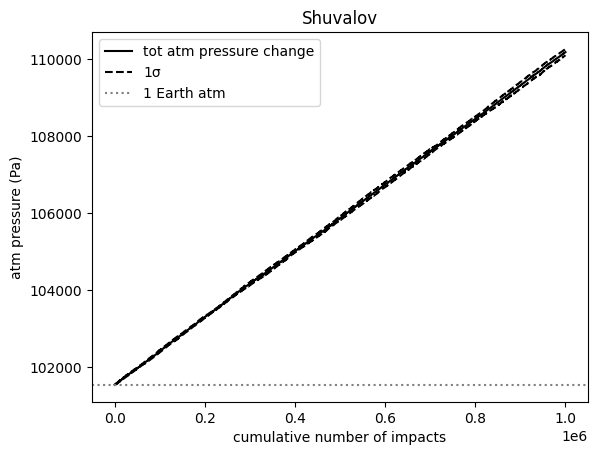

In [35]:
#@title shuvalov plotting
if numruns==1:
  if 'shu' in mods.Nickname.values and outputdataunits=='mass' and atmchange==True:
    plt.scatter(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),shu_M_loss,color='red',label='atm mass lost',s=3)#,marker='o')
    plt.scatter(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),shu_M_gain,color='blue',label='atm mass gained',s=3)#,marker='o')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),shu_delta_M,color='black',label='tot atm mass change',linestyle='dashed')
    plt.legend()
    plt.title("Shuvalov")
    # plt.xscale('log')
    # plt.yscale('log')
    # plt.yscale('symlog')
    plt.xlabel('cumulative number of impacts')
    plt.ylabel('atm mass (kg)')

  if 'shu' in mods.Nickname.values and outputdataunits=='pressure' and atmchange==True:
    # plt.scatter(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),shu_P_loss,color='red',label='atm pressure lost',s=3)#,marker='o')
    # plt.scatter(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),shu_P_gain,color='blue',label='atm pressure gained',s=3)#,marker='o')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),shu_delta_P,color='black',label='tot atm pressure change',linestyle='dashed')
    plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dashed',label='1 Earth atm')
    plt.legend()
    plt.title("Shuvalov")
    # plt.xscale('log')
    # plt.yscale('log')
    # plt.yscale('symlog')
    plt.xlabel('cumulative number of impacts')
    plt.ylabel('atm pressure (Pa)')

  if 'shu' in mods.Nickname.values and outputdataunits=='mass' and atmchange==False:
    plt.plot(r_imp_array,shu_M_loss,color='red',label='atm mass lost')#,marker='o')
    plt.plot(r_imp_array,shu_M_gain,color='blue',label='atm mass gained')#,marker='o')
    plt.plot(r_imp_array,shu_delta_M,color='black',label='tot atm mass change',linestyle='dashed')
    plt.legend()
    plt.title("Shuvalov")
    plt.xscale('log')
    # plt.yscale('log')
    # plt.yscale('symlog')
    plt.xlabel('impactor radius (km)')
    plt.ylabel('mass change (kg)')
    plt.xticks(ticks=[0.1,1,10,100,1000],labels=[0.1,1,10,100,1000])

  if 'shu' in mods.Nickname.values and outputdataunits=='pressure' and atmchange==False:
    plt.plot(r_imp_array,shu_P_loss,color='red',label='atm pressure lost')#,marker='o')
    plt.plot(r_imp_array,shu_P_gain,color='blue',label='atm pressure gained')#,marker='o')
    plt.plot(r_imp_array,shu_delta_P,color='black',label='tot atm pressure change',linestyle='dashed')
    # plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dashed',label='1 Earth atm')
    plt.legend()
    plt.title("Shuvalov")
    plt.xscale('log')
    # plt.yscale('log')
    # plt.yscale('symlog')
    plt.xlabel('impactor radius (km)')
    plt.ylabel('pressure change (Pa)')
    plt.xticks(ticks=[0.1,1,10,100,1000],labels=[0.1,1,10,100,1000])

else:
  if 'shu' in mods.Nickname.values and outputdataunits=='pressure':
    # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['shu'][1]['avg']),yerr=list(processeddatadict['shu'][1]['std']),color='red',label='atm pressure lost')
    # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['shu'][0]['avg']),yerr=list(processeddatadict['shu'][0]['std']),color='blue',label='atm pressure gained')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['shu'][2]['avg']),color='black',label='tot atm pressure change')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['shu'][2]['avg+std']),color='black',label='1σ', linestyle='dashed')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['shu'][2]['avg-std']),color='black', linestyle='dashed')
    plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dotted',label='1 Earth atm')
    plt.legend()
    plt.title("Shuvalov")
    # plt.xscale('log')
    # plt.yscale('log')
    # plt.yscale('symlog')
    plt.xlabel('cumulative number of impacts')
    plt.ylabel('atm pressure (Pa)')

  elif 'shu' in mods.Nickname.values and outputdataunits=='mass':
    # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['shu'][1]['avg']),yerr=list(processeddatadict['shu'][1]['std']),color='red',label='atm mass lost')
    # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['shu'][0]['avg']),yerr=list(processeddatadict['shu'][0]['std']),color='blue',label='atm mass gained')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['shu'][2]['avg']),color='black',label='tot atm mass change')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['shu'][2]['avg+std']),color='black',label='1σ', linestyle='dashed')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['shu'][2]['avg-std']),color='black', linestyle='dashed')
    plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dotted',label='1 Earth atm')
    plt.legend()
    plt.title("Shuvalov")
    # plt.xscale('log')
    # plt.yscale('log')
    # plt.yscale('symlog')
    plt.xlabel('cumulative number of impacts')
    plt.ylabel('atm mass (kg)')


pham plots

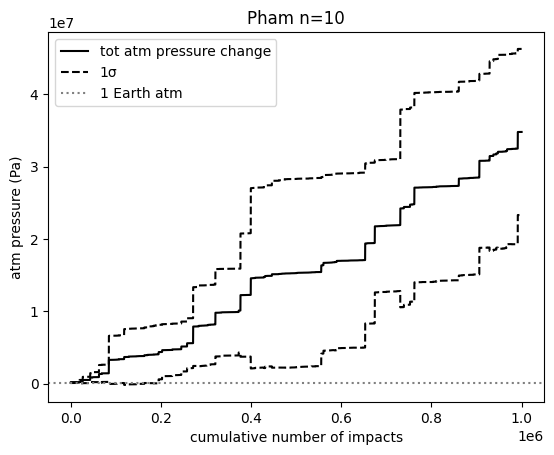

In [36]:
#@title pham10 plotting
if numruns==1:
  if 'pham10' in mods.Nickname.values and outputdataunits=='mass' and atmchange==True:
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),pham10_M_loss,color='red',label='atm mass lost')#,marker='o')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),pham10_M_gain,color='blue',label='atm mass gained')#,marker='o')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),pham10_delta_M,color='black',label='tot atm mass change',linestyle='dashed')
    # plt.axvline(pham10_corresponding_crit_imp_r, color='gray',label='r_imp for m_crit',linestyle='dotted')
    plt.legend()
    plt.title("Pham n=10")
    # plt.xscale('log')
    # plt.yscale('log')
    # plt.yscale('symlog')
    plt.xlabel('cumulative number of impacts')
    plt.ylabel('mass change (kg)')

  if 'pham10' in mods.Nickname.values and outputdataunits=='pressure' and atmchange==True:
    # plt.scatter(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),pham10_P_gain,color='blue',label='atm pressure gained',s=3)#,marker='o')
    # plt.scatter(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),pham10_P_loss,color='red',label='atm pressure lost',s=3)#,marker='o')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),pham10_delta_P,color='black',label='tot atm pressure change',linestyle='dashed')
    plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dashed',label='1 Earth atm')
    plt.legend()
    plt.title("Pham n=10")
    # plt.xscale('log')
    # plt.yscale('log')
    # plt.yscale('symlog')
    plt.xlabel('cumulative number of impacts')
    plt.ylabel('pressure change (Pa)')

  if 'pham10' in mods.Nickname.values and outputdataunits=='mass' and atmchange==False:
    plt.plot(r_imp_array,pham10_M_loss,color='red',label='atm mass lost')#,marker='o')
    plt.plot(r_imp_array,pham10_M_gain,color='blue',label='atm mass gained')#,marker='o')
    plt.plot(r_imp_array,pham10_delta_M,color='black',label='tot atm mass change',linestyle='dashed')
    plt.axvline(pham10_corresponding_crit_imp_r, color='gray',label='r_imp for m_crit',linestyle='dotted')
    plt.legend()
    plt.title("Pham n=10")
    plt.xscale('log')
    # plt.yscale('log')
    # plt.yscale('symlog')
    plt.xlabel('impactor radius (km)')
    plt.ylabel('mass change (kg)')
    plt.xticks(ticks=[0.1,1,10,100,1000],labels=[0.1,1,10,100,1000])

  if 'pham10' in mods.Nickname.values and outputdataunits=='pressure' and atmchange==False:
    plt.plot(r_imp_array,pham10_P_loss,color='red',label='atm pressure lost')#,marker='o')
    plt.plot(r_imp_array,pham10_P_gain,color='blue',label='atm pressure gained')#,marker='o')
    plt.plot(r_imp_array,pham10_delta_P,color='black',label='tot atm pressure change',linestyle='dashed')
    plt.axvline(pham10_corresponding_crit_imp_r, color='gray',label='r_imp for m_crit',linestyle='dotted')
    # plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dashed',label='1 Earth atm')
    plt.legend()
    plt.title("Pham n=10")
    plt.xscale('log')
    # plt.xlim(0.09,0.2)
    # plt.ylim(-1,1.5e7)
    # plt.yscale('log')
    # plt.yscale('symlog')
    plt.xlabel('impactor radius (km)')
    plt.ylabel('pressure change (Pa)')
    plt.xticks(ticks=[0.1,1,10,100,1000],labels=[0.1,1,10,100,1000])

else:
  if 'pham10' in mods.Nickname.values and outputdataunits=='pressure':
    # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['pham10'][1]['avg']),yerr=list(processeddatadict['pham10'][1]['std']),color='red',label='atm pressure lost')
    # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['pham10'][0]['avg']),yerr=list(processeddatadict['pham10'][0]['std']),color='blue',label='atm pressure gained')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['pham10'][2]['avg']),color='black',label='tot atm pressure change')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['pham10'][2]['avg+std']),color='black',label='1σ', linestyle='dashed')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['pham10'][2]['avg-std']),color='black', linestyle='dashed')
    plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dotted',label='1 Earth atm')
    plt.legend()
    plt.title("Pham n=10")
    # plt.xscale('log')
    # plt.yscale('log')
    # plt.yscale('symlog')
    plt.xlabel('cumulative number of impacts')
    plt.ylabel('atm pressure (Pa)')

  elif 'pham10' in mods.Nickname.values and outputdataunits=='mass':
    # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['pham10'][1]['avg']),yerr=list(processeddatadict['pham10'][1]['std']),color='red',label='atm mass lost')
    # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['pham10'][0]['avg']),yerr=list(processeddatadict['pham10'][0]['std']),color='blue',label='atm mass gained')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['pham10'][2]['avg']),color='black',label='tot atm mass change')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['pham10'][2]['avg+std']),color='black',label='1σ', linestyle='dashed')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['pham10'][2]['avg-std']),color='black', linestyle='dashed')
    plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dotted',label='1 Earth atm')
    plt.legend()
    plt.title("Pham n=10")
    # plt.xscale('log')
    # plt.yscale('log')
    # plt.yscale('symlog')
    plt.xlabel('cumulative number of impacts')
    plt.ylabel('atm mass (kg)')

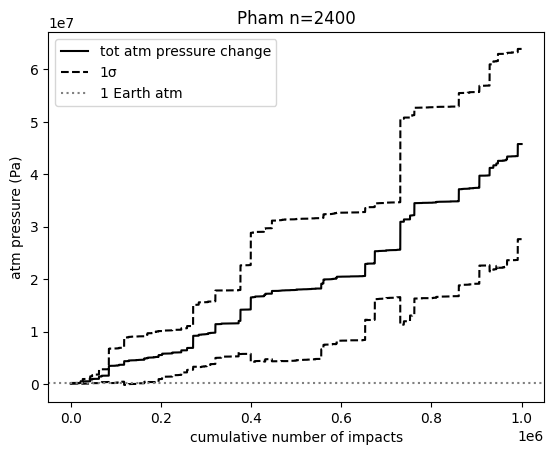

In [37]:
#@title pham2400 plotting
if numruns==1:
  if 'pham2400' in mods.Nickname.values and outputdataunits=='mass' and atmchange==True:
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),pham2400_M_loss,color='red',label='atm mass lost')#,marker='o')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),pham2400_M_gain,color='blue',label='atm mass gained')#,marker='o')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),pham2400_delta_M,color='black',label='tot atm mass change',linestyle='dashed')
    # plt.axvline(pham10_corresponding_crit_imp_r, color='gray',label='r_imp for m_crit',linestyle='dotted')
    plt.legend()
    plt.title("Pham n=2400")
    # plt.xscale('log')
    # plt.yscale('log')
    # plt.yscale('symlog')
    plt.xlabel('cumulative number of impacts')
    plt.ylabel('mass change (kg)')

  if 'pham2400' in mods.Nickname.values and outputdataunits=='pressure' and atmchange==True:
    # plt.scatter(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),pham2400_P_gain,color='blue',label='atm pressure gained',s=3)#,marker='o')
    # plt.scatter(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),pham2400_P_loss,color='red',label='atm pressure lost',s=3)#,marker='o')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),pham2400_delta_P,color='black',label='tot atm pressure change',linestyle='dashed')
    plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dashed',label='1 Earth atm')
    plt.legend()
    plt.title("Pham n=2400")
    # plt.xscale('log')
    # plt.yscale('log')
    # plt.yscale('symlog')
    plt.xlabel('cumulative number of impacts')
    plt.ylabel('pressure change (Pa)')

  if 'pham2400' in mods.Nickname.values and outputdataunits=='mass' and atmchange==False:
    plt.plot(r_imp_array,pham2400_M_loss,color='red',label='atm mass lost')#,marker='o')
    plt.plot(r_imp_array,pham2400_M_gain,color='blue',label='atm mass gained')#,marker='o')
    plt.plot(r_imp_array,pham2400_delta_M,color='black',label='tot atm mass change',linestyle='dashed')
    plt.axvline(pham2400_corresponding_crit_imp_r, color='gray',label='r_imp for m_crit',linestyle='dotted')
    plt.legend()
    plt.title("Pham n=2400")
    plt.xscale('log')
    # plt.yscale('log')
    # plt.yscale('symlog')
    plt.xlabel('impactor radius (km)')
    plt.ylabel('mass change (kg)')
    plt.xticks(ticks=[0.1,1,10,100,1000],labels=[0.1,1,10,100,1000])

  if 'pham2400' in mods.Nickname.values and outputdataunits=='pressure' and atmchange==False:
    plt.plot(r_imp_array,pham2400_P_loss,color='red',label='atm pressure lost')#,marker='o')
    plt.plot(r_imp_array,pham2400_P_gain,color='blue',label='atm pressure gained')#,marker='o')
    plt.plot(r_imp_array,pham2400_delta_P,color='black',label='tot atm pressure change',linestyle='dashed')
    plt.axvline(pham2400_corresponding_crit_imp_r, color='gray',label='r_imp for m_crit',linestyle='dotted')
    # plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dashed',label='1 Earth atm')
    plt.legend()
    plt.title("Pham n=2400")
    plt.xscale('log')
    # plt.xlim(0.09,0.2)
    # plt.ylim(-1,1.5e7)
    # plt.yscale('log')
    # plt.yscale('symlog')
    plt.xlabel('impactor radius (km)')
    plt.ylabel('pressure change (Pa)')
    plt.xticks(ticks=[0.1,1,10,100,1000],labels=[0.1,1,10,100,1000])

else:
  if 'pham2400' in mods.Nickname.values and outputdataunits=='pressure':
    # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['pham2400'][1]['avg']),yerr=list(processeddatadict['pham2400'][1]['std']),color='red',label='atm pressure lost')
    # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['pham2400'][0]['avg']),yerr=list(processeddatadict['pham2400'][0]['std']),color='blue',label='atm pressure gained')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['pham2400'][2]['avg']),color='black',label='tot atm pressure change')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['pham2400'][2]['avg+std']),color='black',label='1σ', linestyle='dashed')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['pham2400'][2]['avg-std']),color='black', linestyle='dashed')
    plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dotted',label='1 Earth atm')
    plt.legend()
    plt.title("Pham n=2400")
    # plt.xscale('log')
    # plt.yscale('log')
    # plt.yscale('symlog')
    plt.xlabel('cumulative number of impacts')
    plt.ylabel('atm pressure (Pa)')

  elif 'pham2400' in mods.Nickname.values and outputdataunits=='mass':
    # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['pham2400'][1]['avg']),yerr=list(processeddatadict['pham2400'][1]['std']),color='red',label='atm mass lost')
    # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['pham2400'][0]['avg']),yerr=list(processeddatadict['pham2400'][0]['std']),color='blue',label='atm mass gained')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['pham2400'][2]['avg']),color='black',label='tot atm mass change')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['pham2400'][2]['avg+std']),color='black',label='1σ', linestyle='dashed')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['pham2400'][2]['avg-std']),color='black', linestyle='dashed')
    plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dotted',label='1 Earth atm')
    plt.legend()
    plt.title("Pham n=2400")
    # plt.xscale('log')
    # plt.yscale('log')
    # plt.yscale('symlog')
    plt.xlabel('cumulative number of impacts')
    plt.ylabel('atm mass (kg)')

Genda and Abe plot

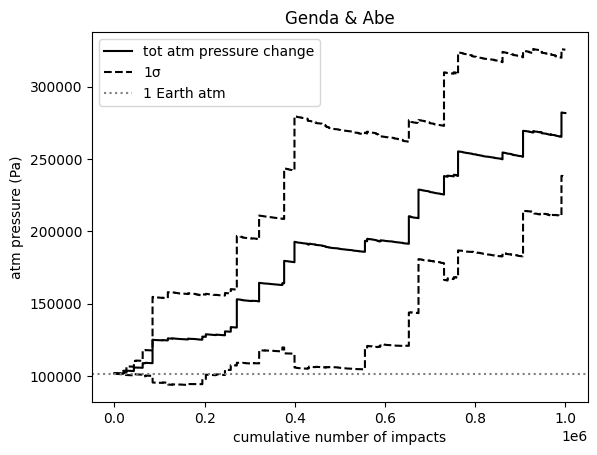

In [38]:
#@title genda and abe plotting
if numruns==1:
  if 'ga' in mods.Nickname.values and outputdataunits=='mass' and atmchange==False:
    plt.plot(r_imp_array,ga_M_loss,color='red',label='atm mass lost')#,marker='o')
    plt.plot(r_imp_array,ga_M_gain,color='blue',label='atm mass gained')#,marker='o')
    plt.plot(r_imp_array,ga_delta_M,color='black',label='tot atm mass change',linestyle='dashed')
    if str(mods.loc[mods['Model Name'] == 'Genda and Abe'].values.tolist()[0][3])=='pham':
      plt.axvline(ga_corresponding_crit_imp_r, color='gray',label='r_imp for m_crit',linestyle='dotted')
    plt.legend()
    plt.title("Genda and Abe")
    plt.xscale('log')
    # plt.yscale('log')
    # plt.yscale('symlog')
    plt.xlabel('impactor radius (km)')
    plt.ylabel('mass change (kg)')
    # plt.ylim(-3.2e6,5e6)
    plt.xticks(ticks=[0.1,1,10,100,1000],labels=[0.1,1,10,100,1000])

  if 'ga' in mods.Nickname.values and outputdataunits=='pressure' and atmchange==False:
    plt.plot(r_imp_array,ga_P_loss,color='red',label='atm pressure lost')#,marker='o')
    plt.plot(r_imp_array,ga_P_gain,color='blue',label='atm pressure gained')#,marker='o')
    # plt.scatter(r_imp_array[-1],atmmass_to_surfacepressure(r_planet,M_imp(rho_imp,r_imp_array[-1])*y_imp,9.8))
    plt.plot(r_imp_array,ga_delta_P,color='black',label='tot atm pressure change',linestyle='dashed')
    # plt.axvline(ga_corresponding_crit_imp_r, color='gray',label='r_imp for m_crit',linestyle='dotted')
    # plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dashed',label='1 Earth atm')
    # plt.axhline(-atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dashed')
    plt.legend()
    plt.title("Genda and Abe")
    plt.xscale('log')
    # plt.yscale('log')
    # plt.yscale('symlog')
    plt.xlabel('impactor radius (km)')
    plt.ylabel('pressure change (Pa)')
    # plt.xlim(4e-3,6e-3)
    # plt.ylim(-6e-5,0)
    # print(atmmass_to_surfacepressure(r_planet,M_imp(rho_imp,r_imp_array[-1])*y_imp,9.8))
    plt.xticks(ticks=[0.1,1,10,100,1000],labels=[0.1,1,10,100,1000])

  if 'ga' in mods.Nickname.values and outputdataunits=='mass' and atmchange==True:
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),ga_M_loss,color='red',label='atm mass lost')#,marker='o')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),ga_M_gain,color='blue',label='atm mass gained')#,marker='o')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),ga_delta_M,color='black',label='tot atm mass change',linestyle='dashed')
    # plt.axvline(ga_corresponding_crit_imp_r, color='gray',label='r_imp for m_crit',linestyle='dotted')
    plt.legend()
    plt.title("Genda and Abe")
    # plt.xscale('log')
    # plt.yscale('log')
    # plt.yscale('symlog')
    plt.xlabel('cumulative number of impacts')
    plt.ylabel('mass change (kg)')

  if 'ga' in mods.Nickname.values and outputdataunits=='pressure' and atmchange==True:
    # plt.scatter(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),ga_P_gain,color='blue',label='atm pressure gained',s=3)#,marker='o')
    # plt.scatter(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),ga_P_loss,color='red',label='atm pressure lost',s=3)#,marker='o')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),ga_delta_P,color='black',label='tot atm pressure change',linestyle='dashed')
    plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dashed',label='1 Earth atm')
    plt.legend()
    plt.title("Genda and Abe")
    # plt.xscale('log')
    # plt.yscale('log')
    # plt.yscale('symlog')
    plt.xlabel('cumulative number of impacts')
    plt.ylabel('pressure change (Pa)')

else:
  if 'ga' in mods.Nickname.values and outputdataunits=='pressure':
    # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['ga'][1]['avg']),yerr=list(processeddatadict['ga'][1]['std']),color='red',label='atm pressure lost')
    # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['ga'][0]['avg']),yerr=list(processeddatadict['ga'][0]['std']),color='blue',label='atm pressure gained')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['ga'][2]['avg']),color='black',label='tot atm pressure change')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['ga'][2]['avg+std']),color='black',label='1σ', linestyle='dashed')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['ga'][2]['avg-std']),color='black', linestyle='dashed')
    plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dotted',label='1 Earth atm')
    plt.legend()
    plt.title("Genda & Abe")
    # plt.xscale('log')
    # plt.yscale('log')
    # plt.yscale('symlog')
    plt.xlabel('cumulative number of impacts')
    plt.ylabel('atm pressure (Pa)')

  elif 'ga' in mods.Nickname.values and outputdataunits=='mass':
    # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['ga'][1]['avg']),yerr=list(processeddatadict['ga'][1]['std']),color='red',label='atm mass lost')
    # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['ga'][0]['avg']),yerr=list(processeddatadict['ga'][0]['std']),color='blue',label='atm mass gained')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['ga'][2]['avg']),color='black',label='tot atm mass change')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['ga'][2]['avg+std']),color='black',label='1σ', linestyle='dashed')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['ga'][2]['avg-std']),color='black', linestyle='dashed')
    plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dotted',label='1 Earth atm')
    plt.legend()
    plt.title("Genda & Abe")
    # plt.xscale('log')
    # plt.yscale('log')
    # plt.yscale('symlog')
    plt.xlabel('cumulative number of impacts')
    plt.ylabel('atm mass (kg)')

svetsov 2000 plot

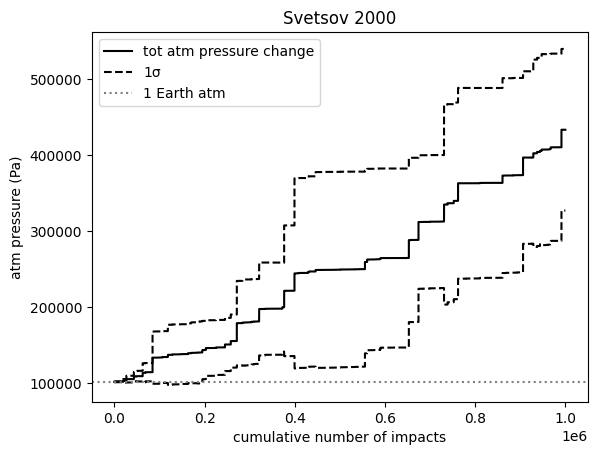

In [39]:
#@title svet 2000 plotting
if numruns==1:
  if 'svet' in mods.Nickname.values and outputdataunits=='mass' and atmchange==False:
    plt.plot(r_imp_array,svet_M_loss,color='red',label='atm mass lost')#,marker='o')
    plt.plot(r_imp_array,svet_M_gain,color='blue',label='atm mass gained')#,marker='o')
    plt.plot(r_imp_array,svet_delta_M,color='black',label='tot atm mass change',linestyle='dashed')
    if str(mods.loc[mods['Model Name'] == 'Svetsov 2000'].values.tolist()[0][3])=='pham':
      plt.axvline(svet_corresponding_crit_imp_r, color='gray',label='r_imp for m_crit',linestyle='dotted')
    plt.legend()
    plt.title("Svetsov 2000")
    plt.xscale('log')
    # plt.yscale('log')
    # plt.yscale('symlog')
    plt.xlabel('impactor radius (km)')
    plt.ylabel('mass change (kg)')
    # plt.ylim(-3.2e6,5e6)
    plt.xticks(ticks=[0.1,1,10,100,1000],labels=[0.1,1,10,100,1000])

  if 'svet' in mods.Nickname.values and outputdataunits=='mass' and atmchange==True:
    # plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),svet_M_loss,color='red',label='atm mass lost')#,marker='o')
    # plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),svet_M_gain,color='blue',label='atm mass gained')#,marker='o')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),svet_delta_M,color='black',label='tot atm mass change',linestyle='dashed')
    plt.legend()
    plt.title("Svetsov 2000")
    # plt.xscale('log')
    # plt.yscale('log')
    # plt.yscale('symlog')
    plt.xlabel('cumulative number of impacts')
    plt.ylabel('mass change (kg)')
    plt.xlim(0.15,0.5)
    plt.ylim(-0.3e11,3.5e11)


  if 'svet' in mods.Nickname.values and outputdataunits=='pressure' and atmchange==False:
    plt.plot(r_imp_array,svet_P_loss,color='red',label='atm pressure lost')#,marker='o')
    plt.plot(r_imp_array,svet_P_gain,color='blue',label='atm pressure gained')#,marker='o')
    plt.plot(r_imp_array,svet_delta_P,color='black',label='tot atm pressure change',linestyle='dashed')
    # plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dashed',label='1 Earth atm')
    # plt.axhline(-atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dashed')
    plt.legend()
    plt.title("Svetsov 2000")
    plt.xscale('log')
    # plt.xlim(0.09,0.2)
    # plt.ylim(-13,13)
    # plt.yscale('log')
    # plt.yscale('symlog')
    # plt.ylim(-2e1,2e5)
    plt.xlabel('impactor radius (km)')
    plt.ylabel('pressure change (Pa)')
    plt.xticks(ticks=[0.1,1,10,100,1000],labels=[0.1,1,10,100,1000])

  if 'svet' in mods.Nickname.values and outputdataunits=='pressure' and atmchange==True:
    # plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),svet_P_loss,color='red',label='atm pressure lost')#,marker='o')
    # plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),svet_P_gain,color='blue',label='atm pressure gained')#,marker='o')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),svet_delta_P,color='black',label='tot atm pressure change',linestyle='dashed')
    plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dashed',label='1 Earth atm')
    # plt.axhline(-atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dashed')
    plt.legend()
    plt.title("Svetsov 2000")
    # plt.xscale('log')
    # plt.yscale('log')
    # plt.yscale('symlog')
    plt.xlabel('cumulative number of impacts')
    plt.ylabel('pressure change (Pa)')
    # plt.xlim(0.15,1.25)
    # plt.ylim(-5e-6,5e-6)
    # plt.xticks(ticks=[0.1,1,10,100,1000],labels=[0.1,1,10,100,1000])

else:
  if 'svet' in mods.Nickname.values and outputdataunits=='pressure':
    # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['svet'][1]['avg']),yerr=list(processeddatadict['svet'][1]['std']),color='red',label='atm pressure lost')
    # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['svet'][0]['avg']),yerr=list(processeddatadict['svet'][0]['std']),color='blue',label='atm pressure gained')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['svet'][2]['avg']),color='black',label='tot atm pressure change')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['svet'][2]['avg+std']),color='black',label='1σ', linestyle='dashed')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['svet'][2]['avg-std']),color='black', linestyle='dashed')
    plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dotted',label='1 Earth atm')
    plt.legend()
    plt.title("Svetsov 2000")
    # plt.xscale('log')
    # plt.yscale('log')
    # plt.yscale('symlog')
    plt.xlabel('cumulative number of impacts')
    plt.ylabel('atm pressure (Pa)')

  elif 'svet' in mods.Nickname.values and outputdataunits=='mass':
    # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['svet'][1]['avg']),yerr=list(processeddatadict['svet'][1]['std']),color='red',label='atm mass lost')
    # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['svet'][0]['avg']),yerr=list(processeddatadict['svet'][0]['std']),color='blue',label='atm mass gained')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['svet'][2]['avg']),color='black',label='tot atm mass change')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['svet'][2]['avg+std']),color='black',label='1σ', linestyle='dashed')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['svet'][2]['avg-std']),color='black', linestyle='dashed')
    plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dotted',label='1 Earth atm')
    plt.legend()
    plt.title("Svetsov 2000")
    # plt.xscale('log')
    # plt.yscale('log')
    # plt.yscale('symlog')
    plt.xlabel('cumulative number of impacts')
    plt.ylabel('atm mass (kg)')

svetsov 2007 plots

/usr/local/lib/python3.10/dist-packages/IPython/core/events.py:89: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


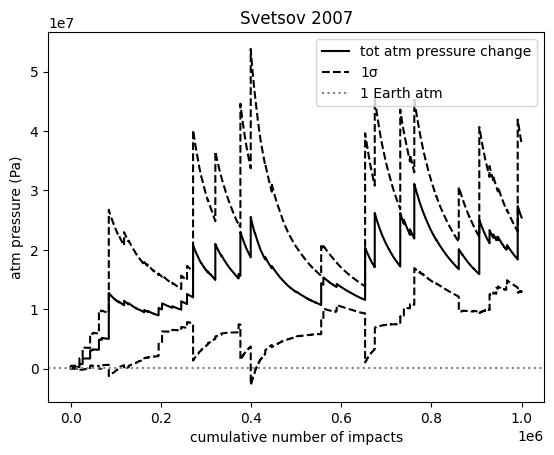

In [40]:
#@title svet 2007 plotting
if numruns==1:
  if 'svet07' in mods.Nickname.values and outputdataunits=='mass' and atmchange==False:
    plt.plot(r_imp_array,svet07_M_loss,color='red',label='atm mass lost')#,marker='o')
    plt.plot(r_imp_array,svet07_M_gain,color='blue',label='atm mass gained')#,marker='o')
    plt.plot(r_imp_array,svet07_delta_M,color='black',label='tot atm mass change',linestyle='dashed')
    plt.legend()
    plt.title("Svetsov 2007")
    plt.xscale('log')
    # plt.yscale('log')
    # plt.yscale('symlog')
    plt.xlabel('impactor radius (km)')
    plt.ylabel('mass change (kg)')
    # plt.ylim(-3.2e6,5e6)
    plt.xticks(ticks=[0.1,1,10,100,1000],labels=[0.1,1,10,100,1000])

  if 'svet07' in mods.Nickname.values and outputdataunits=='mass' and atmchange==True:
    # plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),svet07_M_loss,color='red',label='atm mass lost')#,marker='o')
    # plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),svet07_M_gain,color='blue',label='atm mass gained')#,marker='o')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),svet07_delta_M,color='black',label='tot atm mass change',linestyle='dashed')
    plt.legend()
    plt.title("Svetsov 2007")
    # plt.xscale('log')
    # plt.yscale('log')
    # plt.yscale('symlog')
    plt.xlabel('cumulative number of impacts')
    plt.ylabel('mass change (kg)')
    # plt.xlim(0.1,0.5)
    # plt.ylim(-1.3e10,3.4e11)
    # plt.xticks(ticks=[0.1,1,10,100,1000],labels=[0.1,1,10,100,1000])

  if 'svet07' in mods.Nickname.values and outputdataunits=='pressure' and atmchange==False:
    plt.plot(r_imp_array,svet07_P_loss,color='red',label='atm pressure lost')#,marker='o')
    plt.plot(r_imp_array,svet07_P_gain,color='blue',label='atm pressure gained')#,marker='o')
    plt.plot(r_imp_array,svet07_delta_P,color='black',label='tot atm pressure change',linestyle='dashed')
    # plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dashed',label='1 Earth atm')
    # plt.axhline(-atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dashed')
    plt.legend()
    plt.title("Svetsov 2007")
    plt.xscale('log')
    # plt.xlim(0.1,0.2)
    # plt.ylim(-1e-5,0.4e-3)
    # plt.yscale('log')
    # plt.yscale('symlog')
    # plt.ylim(-1,1e8)
    plt.xlabel('impactor radius (km)')
    plt.ylabel('pressure change (Pa)')
    plt.xticks(ticks=[0.1,1,10,100,1000],labels=[0.1,1,10,100,1000])

  if 'svet07' in mods.Nickname.values and outputdataunits=='pressure' and atmchange==True:
    # plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),svet07_P_loss,color='red',label='atm pressure lost')#,marker='o')
    # plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),svet07_P_gain,color='blue',label='atm pressure gained')#,marker='o')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),svet07_delta_P,color='black',label='tot atm pressure change',linestyle='dashed')
    plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dashed',label='1 Earth atm')
    # plt.axhline(-atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dashed')
    plt.legend()
    plt.title("Svetsov 2007")
    # plt.xscale('log')
    # plt.yscale('log')
    # plt.yscale('symlog')
    plt.xlabel('cumulative number of impacts')
    plt.ylabel('pressure change (Pa)')
    # plt.xlim(0.15,1.25)
    # plt.ylim(0,8e-5)
    # plt.xticks(ticks=[0.1,1,10,100,1000],labels=[0.1,1,10,100,1000])
else:
  if 'svet07' in mods.Nickname.values and outputdataunits=='pressure':
    # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['svet07'][1]['avg']),yerr=list(processeddatadict['svet07'][1]['std']),color='red',label='atm pressure lost')
    # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['svet07'][0]['avg']),yerr=list(processeddatadict['svet07'][0]['std']),color='blue',label='atm pressure gained')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['svet07'][2]['avg']),color='black',label='tot atm pressure change')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['svet07'][2]['avg+std']),color='black',label='1σ', linestyle='dashed')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['svet07'][2]['avg-std']),color='black', linestyle='dashed')
    plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dotted',label='1 Earth atm')
    plt.legend()
    plt.title("Svetsov 2007")
    # plt.xscale('log')
    # plt.yscale('log')
    # plt.yscale('symlog')
    plt.xlabel('cumulative number of impacts')
    plt.ylabel('atm pressure (Pa)')

  elif 'svet07' in mods.Nickname.values and outputdataunits=='mass':
    # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['svet07'][1]['avg']),yerr=list(processeddatadict['svet07'][1]['std']),color='red',label='atm mass lost')
    # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['svet07'][0]['avg']),yerr=list(processeddatadict['svet07'][0]['std']),color='blue',label='atm mass gained')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['svet07'][2]['avg']),color='black',label='tot atm mass change')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['svet07'][2]['avg+std']),color='black',label='1σ', linestyle='dashed')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['svet07'][2]['avg-std']),color='black', linestyle='dashed')
    plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dotted',label='1 Earth atm')
    plt.legend()
    plt.title("Svetsov 2007")
    # plt.xscale('log')
    # plt.yscale('log')
    # plt.yscale('symlog')
    plt.xlabel('cumulative number of impacts')
    plt.ylabel('atm mass (kg)')

In [41]:
for p in svet07_P_gain:
  if p<0:
    print("there's negative values in the svet07 gains for the most recent run")
    break

there's negative values in the svet07 gains for the most recent run


composite

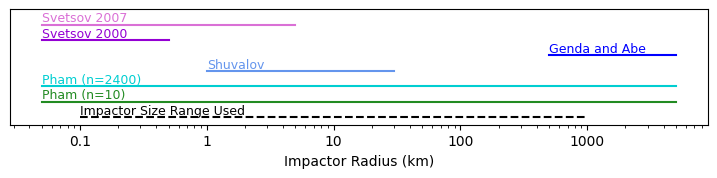

In [42]:
#@title composite plotting

if 'comp' in mods.Nickname.values:
  fig, ax = plt.subplots(figsize=(9,1.5))
  colors=['forestgreen','darkturquoise','cornflowerblue','blue','darkviolet','orchid','gray','peru','red','orange','goldenrod']
  i=0
  for model in sizeregimes:
    i+=1
    plt.plot(sizeregimes[model],[i,i],color=colors[i-1])#,label=model,linewidth=5)
    index=mods.index[mods['Nickname']==model].tolist()[0]
    longmodelname=mods.iloc[index]['Model Name']
    if longmodelname=='Pham':# or longmodelname=='Genda and Abe':
      text=str(longmodelname)+' (n='+str(mods.iloc[index]['n'])+')'
    else:
      text=str(longmodelname)
    ax.text(sizeregimes[model][0], i+0.2, text, size=9,color=colors[i-1])
  # plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
  plt.xscale('log')
  plt.xlabel('Impactor Radius (km)')
  plt.tick_params(left=False, labelleft=False)
  plt.ylim(-0.5,i+1)
  plt.plot([size_lowerbound,size_upperbound],[0,0],color='black',linestyle='dashed')
  plt.xticks(ticks=[0.1,1,10,100,1000],labels=[0.1,1,10,100,1000])
  ax.text(size_lowerbound, 0.2, 'Impactor Size Range Used', size=9,color='black')

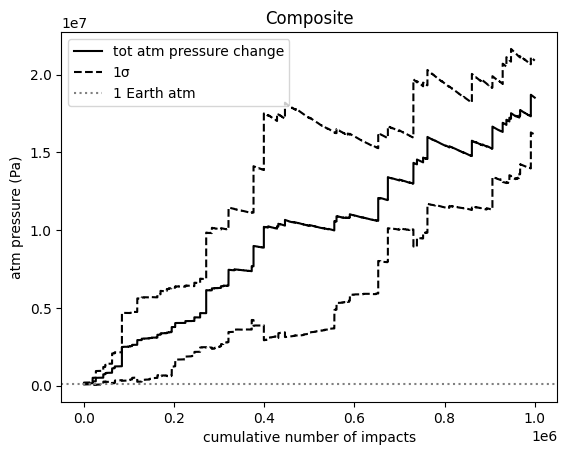

In [43]:
#@title composite plotting cont
if numruns==1:
  if 'comp' in mods.Nickname.values and outputdataunits=='mass' and atmchange==False:
    plt.plot(r_imp_array,comp_M_loss,color='red',label='atm mass lost')#,marker='o')
    plt.plot(r_imp_array,comp_M_gain,color='blue',label='atm mass gained')#,marker='o')
    plt.plot(r_imp_array,comp_delta_M,color='black',label='tot atm mass change',linestyle='dashed')
    plt.legend()
    plt.title("Composite")
    plt.xscale('log')
    # plt.yscale('log')
    # plt.yscale('symlog')
    plt.xlabel('impactor radius (km)')
    plt.ylabel('mass change (kg)')
    # plt.ylim(-1e18,1e18)
    plt.xticks(ticks=[0.1,1,10,100,1000],labels=[0.1,1,10,100,1000])

  if 'comp' in mods.Nickname.values and outputdataunits=='pressure' and atmchange==False:
    plt.plot(r_imp_array,comp_P_loss,color='red',label='atm pressure lost')#,marker='o')
    plt.plot(r_imp_array,comp_P_gain,color='blue',label='atm pressure gained')#,marker='o')
    plt.plot(r_imp_array,comp_delta_P,color='black',label='tot atm pressure change',linestyle='dashed')
    # plt.axvline(ga_corresponding_crit_imp_r, color='gray',label='r_imp for m_crit',linestyle='dotted')
    # plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dashed',label='1 Earth atm')
    # plt.axhline(-atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dashed')
    plt.legend()
    plt.title("Composite")
    plt.xscale('log')
    # plt.xlim(0.09,0.2)
    # plt.ylim(-1e1,2e7)
    plt.yscale('log')
    # plt.yscale('symlog')
    plt.xlabel('impactor radius (km)')
    plt.ylabel('pressure change (Pa)')
    # plt.xticks(ticks=[0.1,1,10,100,1000],labels=[0.1,1,10,100,1000])

  if 'comp' in mods.Nickname.values and outputdataunits=='mass' and atmchange==True:
    # plt.scatter(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),comp_M_loss,color='red',label='atm mass lost')#,marker='o')
    # plt.scatter(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),comp_M_gain,color='blue',label='atm mass gained')#,marker='o')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),comp_delta_M,color='black',label='tot atm mass change',linestyle='dashed')
    plt.legend()
    plt.title("Composite")
    # plt.xscale('log')
    # plt.yscale('log')
    # plt.yscale('symlog')
    plt.xlabel('cumulative number of impacts')
    plt.ylabel('atmospheric mass (kg)')
    # plt.ylim(-1e18,1e18)
    # plt.xticks(ticks=[0.1,1,10,100,1000],labels=[0.1,1,10,100,1000])

  if 'comp' in mods.Nickname.values and outputdataunits=='pressure' and atmchange==True:
    # plt.scatter(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),comp_P_loss,color='red',label='atm pressure lost')
    # plt.scatter(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),comp_P_gain,color='blue',label='atm pressure gained')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),comp_delta_P,color='black',label='tot atm pressure change',linestyle='dashed')
    plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dashed',label='1 Earth atm')
    plt.axhline(110000,color='gray', linestyle='dotted',label='110 kPa')
    # plt.axhline(-atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dashed')
    plt.legend()
    plt.title("Composite")
    # plt.xscale('log')
    # plt.yscale('log')
    # plt.yscale('symlog')
    plt.xlabel('cumulative number of impacts')
    plt.ylabel('atmospheric pressure (Pa)')
    # plt.ylim(-0.1,2e7)
    # plt.xticks(ticks=[0.1,1,10,100,1000],labels=[0.1,1,10,100,1000])

else:
  if 'comp' in mods.Nickname.values and outputdataunits=='pressure':
    # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['comp'][1]['avg']),yerr=list(processeddatadict['comp'][1]['std']),color='red',label='atm pressure lost')
    # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['comp'][0]['avg']),yerr=list(processeddatadict['comp'][0]['std']),color='blue',label='atm pressure gained')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['comp'][2]['avg']),color='black',label='tot atm pressure change')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['comp'][2]['avg+std']),color='black',label='1σ', linestyle='dashed')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['comp'][2]['avg-std']),color='black', linestyle='dashed')
    plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dotted',label='1 Earth atm')
    plt.legend()
    plt.title("Composite")
    # plt.xscale('log')
    # plt.yscale('log')
    # plt.yscale('symlog')
    plt.xlabel('cumulative number of impacts')
    plt.ylabel('atm pressure (Pa)')

  elif 'comp' in mods.Nickname.values and outputdataunits=='mass':
    # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['comp'][1]['avg']),yerr=list(processeddatadict['comp'][1]['std']),color='red',label='atm mass lost')
    # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['comp'][0]['avg']),yerr=list(processeddatadict['comp'][0]['std']),color='blue',label='atm mass gained')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['comp'][2]['avg']),color='black',label='tot atm mass change')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['comp'][2]['avg+std']),color='black',label='1σ', linestyle='dashed')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['comp'][2]['avg-std']),color='black', linestyle='dashed')
    plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dotted',label='1 Earth atm')
    plt.legend()
    plt.title("Composite")
    # plt.xscale('log')
    # plt.yscale('log')
    # plt.yscale('symlog')
    plt.xlabel('cumulative number of impacts')
    plt.ylabel('atm mass (kg)')

plot of the various mass changes

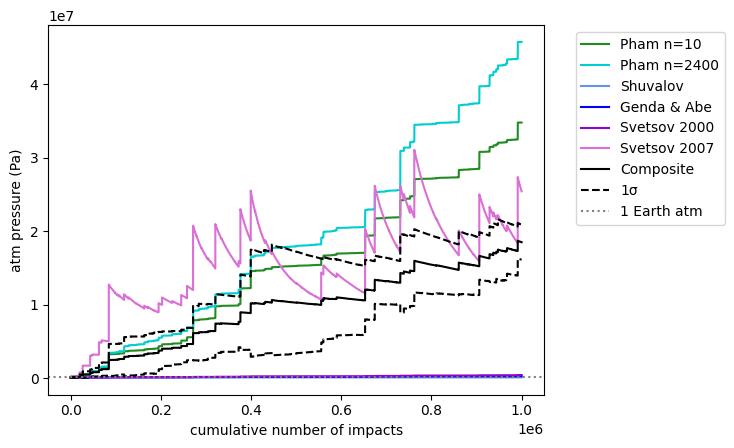

In [44]:
#@title plotting
if numruns==1:
  if outputdataunits=='mass' and atmchange==True:
    # plt.rcParams["figure.figsize"] = (7,7)
    plt.rcParams['ytick.labelsize']=7
    plt.axhline(0,color='gray',linestyle='dotted',label='y=0')
    plt.axhline(5.1e18,color='gray', linestyle='dashed',label='1 Earth atm')
    plt.axhline(-5.1e18,color='gray', linestyle='dashed')
    if 'pham10' in mods.Nickname.values: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),pham10_delta_M,color='forestgreen',label='Pham n=10')
    if 'pham2400' in mods.Nickname.values: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),pham2400_delta_M,color='darkturquoise',label='Pham n=2400')
    if 'shu' in mods.Nickname.values: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),shu_delta_M,color='cornflowerblue',label='Shuvalov')
    if 'ga' in mods.Nickname.values: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),ga_delta_M,color='blue',label='Genda & Abe')
    if 'svet' in mods.Nickname.values: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),svet_delta_M,color='darkviolet',label='Svetsov 2000')
    if 'svet07' in mods.Nickname.values: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),svet07_delta_M,color='orchid',label='Svetsov 2007')
    if 'comp' in mods.Nickname.values: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),comp_delta_M,color='black',label='Composite',linestyle='dashed')

    plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
    # plt.xscale('log')
    plt.yscale('symlog')
    plt.xlabel('cumulative number of impacts')
    plt.ylabel('mass change (kg)')
    plt.ylim(-1e18,1e22)

  if outputdataunits=='pressure' and atmchange==True:
    # plt.rcParams["figure.figsize"] = (7,7)
    plt.rcParams['ytick.labelsize']=7
    plt.axhline(0,color='gray',linestyle='dotted',label='y=0')
    plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dashed',label='1 Earth atm')
    # plt.axhline(-atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dashed')
    if 'pham10' in mods.Nickname.values: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),pham10_delta_P,color='forestgreen',label='Pham n=10')
    if 'pham2400' in mods.Nickname.values: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),pham2400_delta_P,color='darkturquoise',label='Pham n=2400')
    if 'shu' in mods.Nickname.values: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),shu_delta_P,color='cornflowerblue',label='Shuvalov')
    if 'ga' in mods.Nickname.values: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),ga_delta_P,color='blue',label='Genda & Abe')
    if 'svet' in mods.Nickname.values: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),svet_delta_P,color='darkviolet',label='Svetsov 2000')
    if 'svet' in mods.Nickname.values: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),svet07_delta_P,color='orchid',label='Svetsov 2007')
    if 'comp' in mods.Nickname.values: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),comp_delta_P,color='black',label='Composite',linestyle='dashed')

    plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
    # plt.xscale('log')
    plt.yscale('symlog')
    plt.xlabel('cumulative number of impacts')
    plt.ylabel('atmospheric pressure (Pa)')
    # plt.ylim(0.99*min(pham10_delta_P+pham2400_delta_P+shu_delta_P+ga_delta_P+svet_delta_P+svet07_delta_P+comp_delta_P),1.01*max(pham10_delta_P+pham2400_delta_P+shu_delta_P+ga_delta_P+svet_delta_P+svet07_delta_P+comp_delta_P))
    # plt.ylim(-0.8e3,0.5e6)
    # plt.xlim(4.5e-3,5.7e-3)
    # plt.ylim(-0.6e-4,1e-4)

  if outputdataunits=='mass' and atmchange==False:
    # plt.rcParams["figure.figsize"] = (7,7)
    plt.rcParams['ytick.labelsize']=7
    plt.axhline(0,color='gray',linestyle='dotted',label='y=0')
    plt.axhline(5.1e18,color='gray', linestyle='dashed',label='1 Earth atm')
    plt.axhline(-5.1e18,color='gray', linestyle='dashed')
    if 'pham10' in mods.Nickname.values: plt.plot(r_imp_array,pham10_delta_M,color='forestgreen',label='Pham n=10')
    if 'pham2400' in mods.Nickname.values: plt.plot(r_imp_array,pham2400_delta_M,color='darkturquoise',label='Pham n=2400')
    if 'shu' in mods.Nickname.values: plt.plot(r_imp_array,shu_delta_M,color='cornflowerblue',label='Shuvalov')
    if 'ga' in mods.Nickname.values: plt.plot(r_imp_array,ga_delta_M,color='blue',label='Genda & Abe')
    if 'svet' in mods.Nickname.values: plt.plot(r_imp_array,svet_delta_M,color='darkviolet',label='Svetsov 2000')
    if 'svet07' in mods.Nickname.values: plt.plot(r_imp_array,svet07_delta_M,color='orchid',label='Svetsov 2007')
    if 'comp' in mods.Nickname.values: plt.plot(r_imp_array,comp_delta_M,color='black',label='Composite',linestyle='dashed')

    plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
    plt.xscale('log')
    plt.yscale('symlog')
    plt.xlabel('impactor radius (km)')
    plt.ylabel('mass change (kg)')
    plt.ylim(-1e18,1e22)
    plt.xticks(ticks=[0.1,1,10,100,1000],labels=[0.1,1,10,100,1000])

  if outputdataunits=='pressure' and atmchange==False:
    # plt.rcParams["figure.figsize"] = (7,7)
    plt.rcParams['ytick.labelsize']=7
    plt.axhline(0,color='gray',linestyle='dotted',label='y=0')
    plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dashed',label='1 Earth atm')
    plt.axhline(-atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dashed')
    if 'pham10' in mods.Nickname.values: plt.plot(r_imp_array,pham10_delta_P,color='forestgreen',label='Pham n=10')
    if 'pham2400' in mods.Nickname.values: plt.plot(r_imp_array,pham2400_delta_P,color='darkturquoise',label='Pham n=2400')
    if 'shu' in mods.Nickname.values: plt.plot(r_imp_array,shu_delta_P,color='cornflowerblue',label='Shuvalov')
    if 'ga' in mods.Nickname.values: plt.plot(r_imp_array,ga_delta_P,color='blue',label='Genda & Abe')
    if 'svet' in mods.Nickname.values: plt.plot(r_imp_array,svet_delta_P,color='darkviolet',label='Svetsov 2000')
    if 'svet' in mods.Nickname.values: plt.plot(r_imp_array,svet07_delta_P,color='orchid',label='Svetsov 2007')
    if 'comp' in mods.Nickname.values: plt.plot(r_imp_array,comp_delta_P,color='black',label='Composite',linestyle='dashed')

    plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
    plt.xscale('log')
    plt.yscale('symlog')
    plt.xlabel('impactor radius (km)')
    plt.ylabel('pressure change (Pa)')
    # plt.ylim(-0.5e4,0.2e9)
    plt.ylim(-1e2,1e8)
    plt.xticks(ticks=[0.1,1,10,100,1000],labels=[0.1,1,10,100,1000])

else:
  if outputdataunits=='pressure':
    plotunc=False
    compplotunc=True
    if 'pham10' in mods.Nickname.values:  plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['pham10'][2]['avg']),color='forestgreen',label='Pham n=10')
    if plotunc==True: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['pham10'][2]['avg+std']),color='forestgreen', linestyle='dashed'); plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['pham10'][2]['avg-std']),color='forestgreen', linestyle='dashed')
    if 'pham2400' in mods.Nickname.values:  plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['pham2400'][2]['avg']),color='darkturquoise',label='Pham n=2400')
    if plotunc==True: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['pham2400'][2]['avg+std']),color='darkturquoise', linestyle='dashed'); plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['pham2400'][2]['avg-std']),color='darkturquoise', linestyle='dashed')
    if 'shu' in mods.Nickname.values:  plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['shu'][2]['avg']),color='cornflowerblue',label='Shuvalov')
    if plotunc==True: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['shu'][2]['avg+std']),color='cornflowerblue', linestyle='dashed'); plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['shu'][2]['avg-std']),color='cornflowerblue', linestyle='dashed')
    if 'ga' in mods.Nickname.values:  plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['ga'][2]['avg']),color='blue',label='Genda & Abe')
    if plotunc==True: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['ga'][2]['avg+std']),color='blue', linestyle='dashed'); plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['ga'][2]['avg-std']),color='blue', linestyle='dashed')
    if 'svet' in mods.Nickname.values: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['svet'][2]['avg']),color='darkviolet',label='Svetsov 2000')
    if plotunc==True: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['svet'][2]['avg+std']),color='darkviolet', linestyle='dashed'); plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['svet'][2]['avg-std']),color='darkviolet', linestyle='dashed')
    if 'svet07' in mods.Nickname.values: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['svet07'][2]['avg']),color='orchid',label='Svetsov 2007')
    if plotunc==True: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['svet07'][2]['avg+std']),color='orchid', linestyle='dashed'); plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['svet07'][2]['avg-std']),color='orchid', linestyle='dashed')
    if 'comp' in mods.Nickname.values: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['comp'][2]['avg']),color='black',label='Composite')
    if compplotunc==True: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['comp'][2]['avg+std']),color='black', linestyle='dashed', label='1σ'); plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['comp'][2]['avg-std']),color='black', linestyle='dashed')

    plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dotted',label='1 Earth atm')
    plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
    # plt.xscale('log')
    # plt.yscale('log')
    # plt.yscale('symlog')
    plt.xlabel('cumulative number of impacts')
    plt.ylabel('atm pressure (Pa)')

  elif outputdataunits=='mass':
    plotunc=False
    compplotunc=True
    if 'pham10' in mods.Nickname.values:  plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['pham10'][2]['avg']),color='forestgreen',label='Pham n=10')
    if plotunc==True: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['pham10'][2]['avg+std']),color='forestgreen', linestyle='dashed'); plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['pham10'][2]['avg-std']),color='forestgreen', linestyle='dashed')
    if 'pham2400' in mods.Nickname.values:  plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['pham2400'][2]['avg']),color='darkturquoise',label='Pham n=2400')
    if plotunc==True: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['pham2400'][2]['avg+std']),color='darkturquoise', linestyle='dashed'); plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['pham2400'][2]['avg-std']),color='darkturquoise', linestyle='dashed')
    if 'shu' in mods.Nickname.values:  plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['shu'][2]['avg']),color='cornflowerblue',label='Shuvalov')
    if plotunc==True: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['shu'][2]['avg+std']),color='cornflowerblue', linestyle='dashed'); plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['shu'][2]['avg-std']),color='cornflowerblue', linestyle='dashed')
    if 'ga' in mods.Nickname.values:  plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['ga'][2]['avg']),color='blue',label='Genda & Abe')
    if plotunc==True: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['ga'][2]['avg+std']),color='blue', linestyle='dashed'); plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['ga'][2]['avg-std']),color='blue', linestyle='dashed')
    if 'svet' in mods.Nickname.values: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['svet'][2]['avg']),color='darkviolet',label='Svetsov 2000')
    if plotunc==True: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['svet'][2]['avg+std']),color='darkviolet', linestyle='dashed'); plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['svet'][2]['avg-std']),color='darkviolet', linestyle='dashed')
    if 'svet07' in mods.Nickname.values: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['svet07'][2]['avg']),color='orchid',label='Svetsov 2007')
    if plotunc==True: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['svet07'][2]['avg+std']),color='orchid', linestyle='dashed'); plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['svet07'][2]['avg-std']),color='orchid', linestyle='dashed')
    if 'comp' in mods.Nickname.values: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['comp'][2]['avg']),color='black',label='Composite')
    if compplotunc==True: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['comp'][2]['avg+std']),color='black', linestyle='dashed', label='1σ'); plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['comp'][2]['avg-std']),color='black', linestyle='dashed')

    plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dotted',label='1 Earth atm')
    plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
    # plt.xscale('log')
    # plt.yscale('log')
    # plt.yscale('symlog')
    plt.xlabel('cumulative number of impacts')
    plt.ylabel('atm mass (kg)')

to dos:
* certain impactors not making it to the surface (functions are defined, but not used)
* velocity distribution
* comet vs asteroid distribution
* drag

below here are bits of garbage code

In [45]:
#@title garbage code

# def closest(lst, K):
#     return lst[min(range(len(lst)), key = lambda i: abs(lst[i]-K))]

# def findvars(modelnickname):
#   for i in range(len(mods['Model Name'])):
#     if mods.loc[i,'Nickname']==modelnickname:
#       rownumber=i
#   M_loss=mods['Losses List Variable Name'][rownumber]
#   M_gain=mods['Gains List Variable Name'][rownumber]
#   M_delta=mods['Delta List Variable Name'][rownumber]

#   return M_loss, M_gain, M_delta

# def builddict(modelnickname,losslist,gainlist,deltalist):
#   variablenames=findvars(modelnickname)
#   M_loss_name=variablenames[0]
#   M_gain_name=variablenames[1]
#   M_delta_name=variablenames[2]

#   return {M_loss_name: losslist, M_gain_name: gainlist, M_delta_name: deltalist}



# def oldga_m_atm_gain(rho_imp,r_imp,y_imp): #not used. instead using pham model with n=200 for the gain
#   m_imp=M_imp(rho_imp,r_imp)
#   return y_imp*m_imp

# def oldgagain(r_imp_array,rho_imp,y_imp): #not used. instead using pham model gain w/ n=200
#   m_gain=[]
#   for r_imp in r_imp_array:
#     M_gain=oldga_m_atm_gain(rho_imp,r_imp,y_imp)
#     m_gain.append(M_gain)
#   return m_gain


# sizeregimes={'pham10': [5.,500.], 'pham2400':[10.,500.], 'shu': [5.,500.], 'ga': [500.,5000.], 'svet': [0.05,0.5], 'svet07': [0.05,5.]}
# #Svetsov 2000 is 0.1-1 km diameter impactors, Svetsov 2007 is 0.1-10 km diameter impactors, and Genda & Abe is Mars sized impactors (𝒪 ~1000 km diameters)
# #mika here pham & shu are garbage numbers for now. Jules will supply actual values

# modelstocombine=list(sizeregimes.keys())

# overallrange=[size_lowerbound,size_upperbound]

# #the 3 for loops below trim the size regimes to fit our upper and lower bounds and deletes any models that are outside our bounds
# for model in modelstocombine:
#   if sizeregimes[model][0]>size_upperbound:
#     del sizeregimes[model]

# modelstocombine=list(sizeregimes.keys())

# for model in modelstocombine:
#   if sizeregimes[model][1]<size_lowerbound:
#     del sizeregimes[model]

# modelstocombine=list(sizeregimes.keys())

# for model in modelstocombine:
#   if sizeregimes[model][0]<size_lowerbound:
#     sizeregimes[model][0]=size_lowerbound
#   if sizeregimes[model][1]>size_upperbound:
#     sizeregimes[model][1]=size_upperbound



# #need to find the overlap intervals between the models so we can average them in those intervals
# combinationslist=[]
# for i in range(len(modelstocombine)-1):
#   combinationslist=combinationslist+list(itertools.combinations(modelstocombine, i+2))
# #makes a list of all the combinations of the models. every 2 item combo thru every 6 item combo if there's 6 models

# class overlap: #gives the overlapping intervals of a number of intervals given
#    def solve(self, intervals):
#       start, end = intervals.pop()
#       while intervals:
#          start_temp, end_temp = intervals.pop()
#          start = max(start, start_temp)
#          end = min(end, end_temp)
#       if start<end:
#         return [start, end]
#       else:
#         return None
# ob = overlap()


# intervalslist=[]
# i=0
# for combo in combinationslist:
#   combo=list(combo)
#   # print(combo)
#   combinationslist[i]=combo
#   miniintervallist=[]
#   for model in combo:
#     miniintervallist.append(sizeregimes[model])
#   intervalslist.append(miniintervallist)
#   i+=1

# comboregimes={}
# for i,j,k in zip(combinationslist,intervalslist,range(0,len(combinationslist))):
#   comboregimes[k]=[i,j]
# #now comboregimes is a dictionary where the values are a list of the form [[combination],[regimes]]


# #have the lists of keys to compare
# #have a dict with the ranges for each
# #need to compare the lists of key's dict ranges to each other to figure out where overlap is

# overlaps={}
# for key in comboregimes:
#   intervals=comboregimes[key][1]
#   isoverlap=ob.solve(intervals)
#   if isoverlap != None:
#     overlaps[key]=[comboregimes[key][0],isoverlap]

# #ok we want none of the intervals to overlap
# # for key in overlaps:
# #   print(key,overlaps[key])

# overlapskeys=list(overlaps.keys())
# for key1 in overlapskeys:
#   for key2 in overlapskeys:
#     if overlaps[key1][1]==overlaps[key2][1]:
#       if len(overlaps[key1][0])>len(overlaps[key2][0]):
#         del overlaps[key2]

# for key in overlaps:
#   print(key,overlaps[key])



# loca=mods.loc[mods['Model Name'] == 'Genda and Abe']
# print(loca)
# loca=loca.values.tolist()[0]
# print(loca)
# print(loca[3])
# merp=mods.loc[mods['Model Name'] == 'Genda and Abe'].values.tolist()[0][3]
# print(merp)


# print(randomlychosensizevals[0:50])

# seen = set()
# for i, e in enumerate(randomlychosensizevals):
#     if e in seen:
#         randomlychosensizevals[i] = e+np.random.uniform(0.,0.001) #adding a little extra wiggle so there's no repeats, which will mess up a dictionary used in the composite model
#     else:
#         seen.add(e)

# print(randomlychosensizevals[0:50])

In [46]:
# for j in range(len(mods['Model Name'])):
#   if mods['Model Name'][j]=='Pham':
#     n=float(mods['n'][j])
#     if n==10.:
#       if outputdataunits=='pressure':
#         pham10gainarray=pham10_P_gain
#         pham10lossarray=pham10_P_loss
#         pham10deltaarray=pham10_delta_P
#       elif outputdataunits=='mass':
#         pham10gainarray=pham10_M_gain
#         pham10lossarray=pham10_M_loss
#         pham10deltaarray=pham10_delta_M
#       else:
#         print('output data units',outputdataunits,'not recognized')

#       listofpham10gains.append(pham10gainarray)
#       listofpham10losses.append(pham10lossarray)
#       listofpham10deltas.append(pham10deltaarray)
#     elif n==2400.:
#       ###################
#     else:
#       print('n =',n,'not recognized')
#       print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')

#   elif mods['Model Name'][j]=='Shuvalov':
#     ###################

#   elif mods['Model Name'][j]=='Genda and Abe':
#     ###################

#   elif  mods['Model Name'][j]=='Svetsov 2000':
#     ###################

#   elif mods['Model Name'][j]=='Svetsov 2007':
#     ###################

#   elif mods['Model Name'][j]=='Composite':
#     ###################

#   else:
#     print('model',mods['Model Name'][j],'not recognized')
#     print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')
#   #mika here need to modify (add more elifs) as you add more models


# if numruns==1:
#   runmodels()
# else:
#   listofmodelgains,listofmodellosses,listofmodeldeltas=[],[],[]
#   for numrun in range(1,numruns+1):
#     print('run number',numrun)
#     r_imp_array=r_imp_arrays[numrun]
#     runmodels()
#     if outputdataunits=='pressure':
#       modelgainarray=svet_P_gain
#       modellossarray=svet_P_loss
#       modeldeltaarray=svet_delta_P
#     elif outputdataunits=='mass':
#       modelgainarray=svet_M_gain
#       modellossarray=svet_M_loss
#       modeldeltaarray=svet_delta_M
#     else:
#       print('output data units',outputdataunits,'not recognized')

#     listofmodelgains.append(modelgainarray)
#     listofmodellosses.append(modellossarray)
#     listofmodeldeltas.append(modeldeltaarray)

#   modelgaindict = {}
#   modellossdict = {}
#   modeldeltadict = {}

#   for numrun in range(1,numruns+1):
#     modelgaindict[numrun] = listofmodelgains[numrun-1]
#     modellossdict[numrun] = listofmodellosses[numrun-1]
#     modeldeltadict[numrun] = listofmodeldeltas[numrun-1]

#   model_gain_arrays = pd.DataFrame(modelgaindict)
#   model_loss_arrays = pd.DataFrame(modellossdict)
#   model_delta_arrays = pd.DataFrame(modeldeltadict)
#   if printdatatables==True:
#     print('model gain array')
#     display(model_gain_arrays)
#     print('model loss array')
#     display(model_loss_arrays)
#     print('model delta array')
#     display(model_delta_arrays)